## Fintech 545 – Quantitative Risk Management  
**Final Paper**   
Felipe Jaramillo Penagos  

## 1. Quantitative Portfolio Management (MVO)
* Markowitz was the first to provide a rigorous mathematical formalization of diversification. He demonstrated that a portfolio’s total risk, which he quantified using the statistical concept of variance, was not merely the average of individual asset risks. Instead, it was a complex function of the assets’ individual variances and, critically, their pairwise covariances
*  This meant that a highly volatile asset could, counterintuitively, reduce the overall risk of a portfolio if its returns tended to move in opposition to the other assets , that is, if it had a low or negative correlation with them
* Risk could be reduced without sacrificing expected return
* The MVO framework is built upon two key statistical measures: the expected return and the variance of the total portfolio.\
### 1.2 Mathematical Framework of MVO
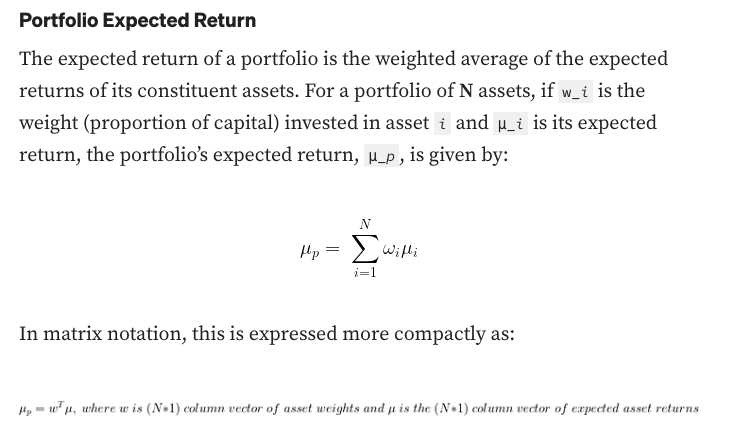
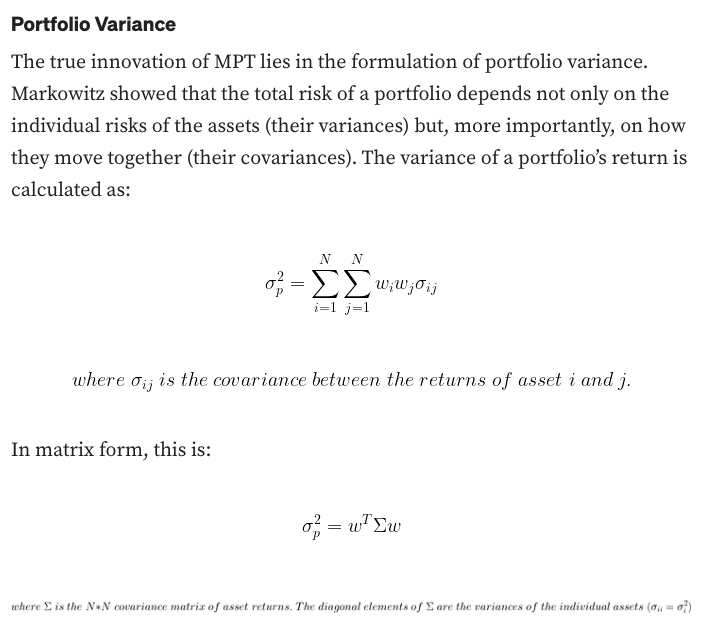  

**Note**: This formulation reveals a critical property of diversification: for a portfolio of N assets, there are N variance terms but N^2−N covariance terms. As the number of assets increases, the portfolio’s total risk becomes overwhelmingly dominated by the covariance terms, underscoring the paramount importance of correlation in portfolio construction.

* The set of all such optimal portfolios, when plotted in risk-return space (with standard deviation σ_p​ on the x-axis and expected return μ_p​ on the y-axis), forms a curve known as the Efficient Frontier. This curve is hyperbolic in shape and is sometimes referred to as the “Markowitz Bullet”. Any portfolio that lies on the upper part of this curve is “efficient.”

### 1.3 The MVO Optimization Problem - Constrained Quadratic Programming
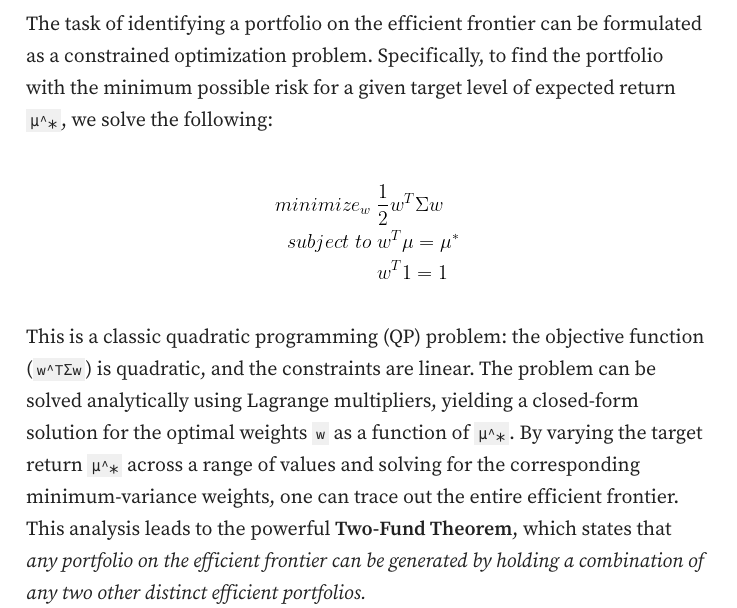

### 1.4 The Tangency Line: Maximizing the Sharpe Ration (CML)
* The MVO framework becomes even more powerful with the introduction of a risk-free asset, an investment with zero variance (e.g., a short-term government bill) that yields a certain return r_f​. An investor can now form a portfolio by combining this risk-free asset with a portfolio of risky assets. The set of all such combinations forms a straight line in risk-return space, originating at (0,r_f​) and passing through the chosen risky portfolio.

* The optimal combination line is the one with the highest possible slope, as it offers the greatest return per unit of risk. This line, known as the Capital Market Line (CML), is the one that is tangent to the efficient frontier of risky assets. The specific portfolio of risky assets at the point of tangency is known as the Tangency Portfolio or the Maximum Sharpe Ratio (MSR) Portfolio. It is the optimal portfolio of risky assets for all investors, regardless of their risk tolerance. An investor’s desired risk level is then achieved by allocating capital between this single MSR portfolio and the risk-free asset.

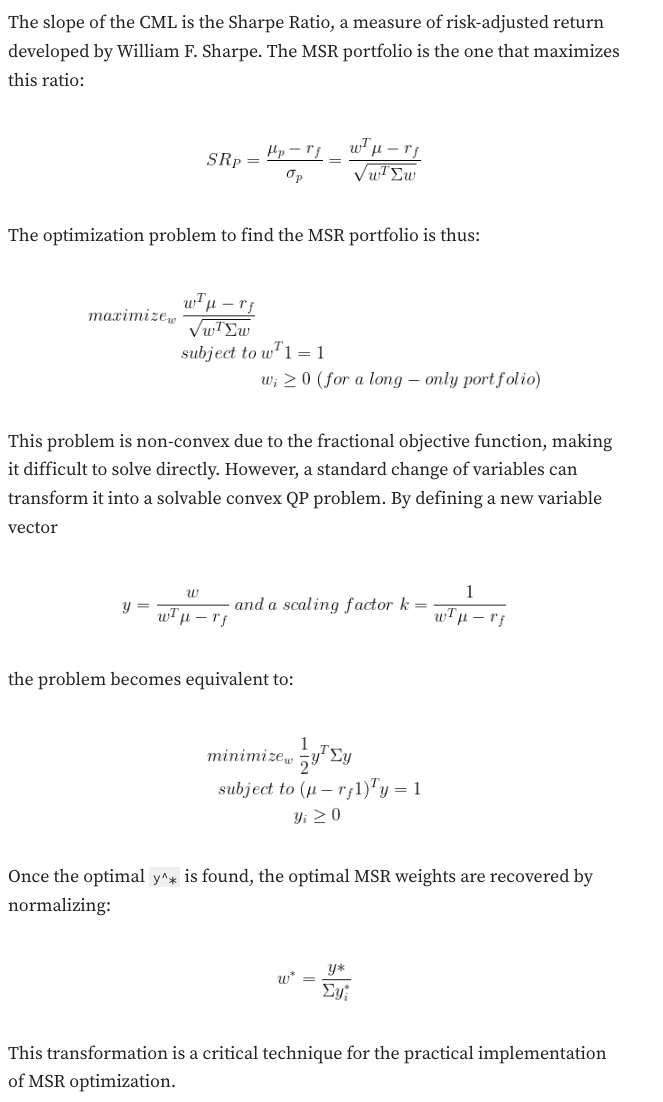

* The elegance of this mathematical framework, however, conceals a severe practical vulnerability. An optimizer’s purpose is to find the absolute maximum of the objective function. When that function is the Sharpe Ratio, the optimizer will aggressively allocate capital to assets with even slightly overestimated expected returns and away from those with slightly underestimated returns. Because expected returns (μ) are notoriously difficult to forecast with precision, the MVO process does not merely use the estimation errors present in the inputs; it actively seeks them out and amplifies their impact on the final portfolio. This phenomenon, often called “error maximization,” results in portfolios that are theoretically optimal but practically unstable, often concentrated in a few assets, and poorly performing out-of-sample. This fundamental flaw is the primary motivation behind the evolution toward more robust allocation methodologies.

## 2. Risk Parity: Risk-Based Allocation
* The practical challenges of MVO, particularly its sensitivity to return forecasts, spurred the development of alternative asset allocation frameworks. Risk Parity emerged as a powerful paradigm by reframing the core problem: instead of optimizing a portfolio based on uncertain return forecasts, it seeks to build a portfolio based on the more stable and observable characteristic of risk.

### 2.2 The Mathematics of Risk Contribution
* To implement Risk Parity, one must first be able to decompose total portgfolio risk into contributions from each asset
* The standard deviation of a portfolio, $ σ_p​(w)=sqrt(w^TΣw​) $, is a homogeneous function of degree one with respect to the weights w. This means that for any scalar $ λ>0, σ_p​(λw)=λσ_p​(w) $. This property allows for the application of Euler’s Homogeneous Function Theorem, which provides a mathematically sound basis for risk decomposition.

**Marginal Contribution to Risk**: MCR
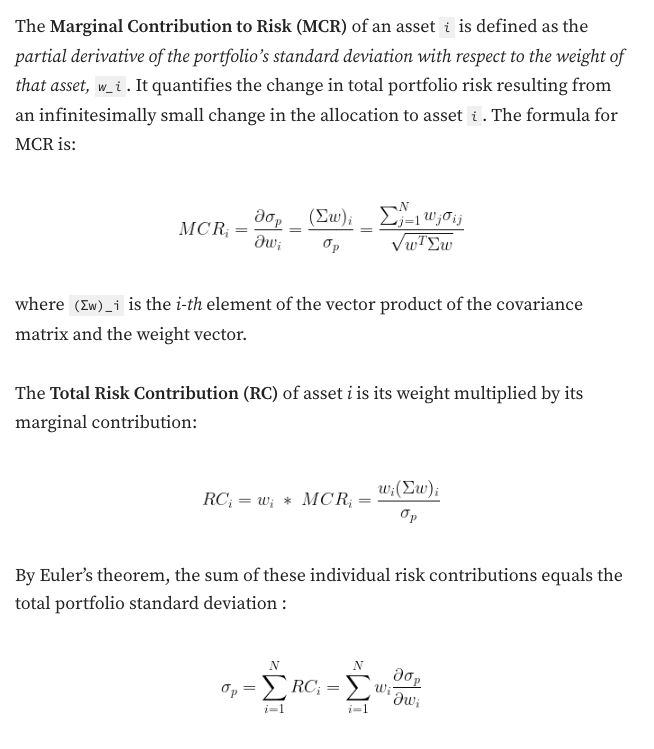
* This elegant result provides an additive decomposition of a non-additive risk measure, allowing portfolio managers to precisely quantify how much each asset is contributing to the portfolio’s overall risk.

### Non-liner Optimization: Risk Parity Optimization Problem
The objective of a “true” Risk Parity or Equal Risk Contribution (ERC) portfolio is to find a weight vector w such that the risk contribution from each asset is identical

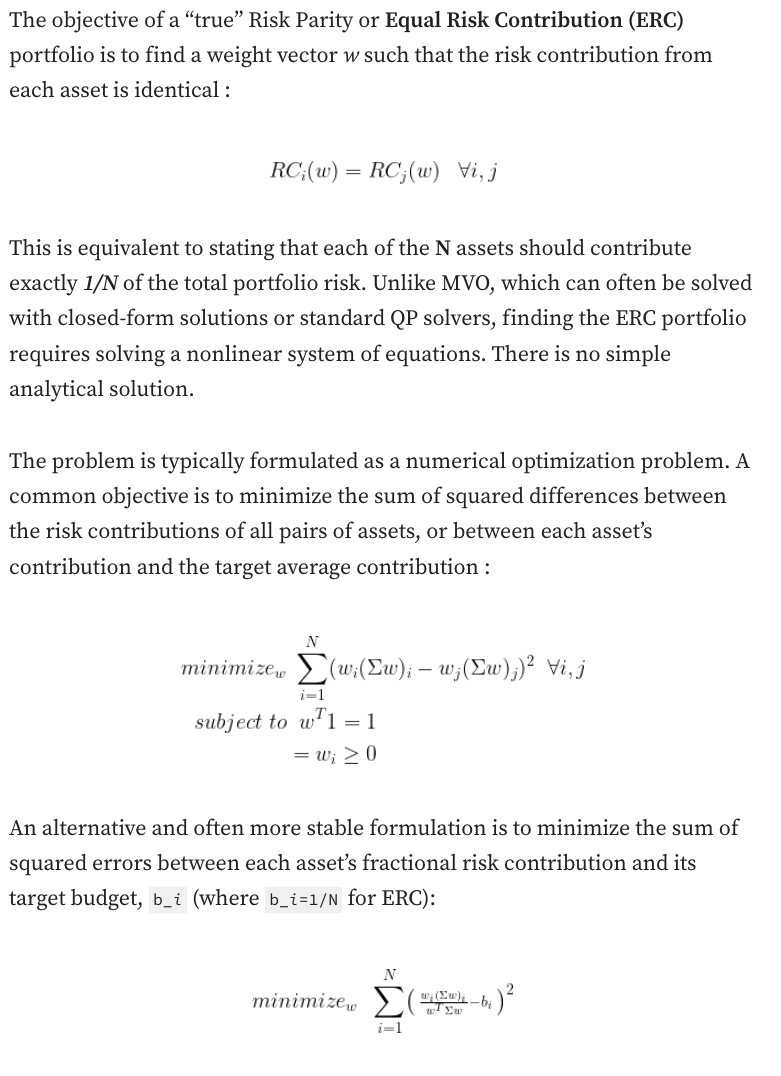

* This is a nonlinear, non-convex optimization problem that must be solved using iterative numerical algorithms, such as Sequential Least Squares Programming (SLSQP), which is well-suited for handling nonlinear objectives with linear constraints.

* The decision to ignore expected returns is often presented as Risk Parity’s primary strength, but it rests on a profound, implicit assumption: that all asset classes offer a similar long-term risk-adjusted return (Sharpe ratio). If this were true, then equalizing risk contributions would be the most rational path to a well-diversified portfolio. Therefore, Risk Parity does not eliminate the need for a view on returns; rather, it replaces the granular, difficult task of forecasting individual asset returns with a single, broad, philosophical belief about the long-term efficiency of markets in pricing risk.

* Furthermore, the mechanics of the ERC optimization reveal a sophisticated approach to diversification. The risk contribution of an asset is driven by its own volatility and its covariance with every other asset in the portfolio. An asset that is highly correlated with the portfolio will have a high MCR. To satisfy the equal-risk objective, the optimizer must systematically reduce the weight of such assets. This means the ERC framework inherently penalizes assets that fail to provide diversification benefits and rewards those with low correlations, making it a far more intelligent approach than naive inverse-volatility weighting.

## 3. Comparative Analysis: MVO vs RP
### 3.1. Estimation Error and Robustness
1. MVO’s Achilles’ Heel: The greatest practical weakness of MVO is its extreme sensitivity to its inputs
2. The optimization process requires two sets of parameters: the vector of expected returns (μ) and the covariance matrix (Σ). Of these, expected returns are notoriously difficult to estimate with any degree of accuracy
3. **Risk Parity's relative stability**: Its sole required input is the covariance matrix, Σ. While Σ is also an estimate and subject to error, second moments of return distributions (variances and covariances) are empirically far more stable and predictable through time than first moments (mean returns)  

MVO is theoretically optimal under the impossible condition that its inputs are known with perfect certainty. Risk Parity, conversely, is designed to be robust to the practical reality that these inputs, especially expected returns, are highly uncertain

### 3.2. Leverage
* key feature of an **unlevered** ERC portfolio is its significant allocation to low-risk, low-return assets like government bonds. Consequently, its overall expected return is often too low to meet the objectives of most institutional investors. 
* To address this, leverage is not an optional add-on but a core, structural component of the Risk Parity strategy. The well-diversified, low-risk base portfolio is levered up to a risk level comparable to that of a traditional portfolio (e.g., a 60/40), thereby scaling up its expected return as well.

* A levered RP portfolio might target the same 10% annual volatility as a 60/40 portfolio. The crucial difference lies in the composition of that risk. The 60/40 portfolio’s risk is almost entirely driven by equities, whereas the RP portfolio’s risk is derived from a balanced mix of different asset classes, amplified by leverage.

* Pros and Cons of Leverage: leverage introduces its own set of significant risks. These include path dependency, where a series of short-term losses can trigger margin calls and force liquidation at inopportune times, and a heightened vulnerability to systemic shocks where correlations across all asset classes converge to one, nullifying diversification benefits.

### 3.3. Diversification
MVO: Capital Diversification: MVO seeks to achieve diversification by combining assets with low or negative correlations. The goal is to construct a portfolio that is optimal with respect to a specific forecast of risk and return. However, as discussed, the optimization process can paradoxically lead to portfolios that are highly concentrated in a small subset of the available asset classes, undermining the goal of diversification.

Learn about Medium’s values
Risk Parity: Risk Factor Diversification: Risk Parity approaches diversification from a more fundamental perspective. The goal is not just to diversify across asset tickers but to diversify across underlying economic risk factors. By balancing contributions from asset classes that perform well in different economic environments , such as rising growth (equities), falling growth (bonds), rising inflation (commodities), and falling inflation (bonds), the strategy aims to build a portfolio that is robust to macroeconomic surprises. This represents a deeper form of diversification, focused on resilience across economic regimes rather than optimality within a single forecasted scenario.

## 5. Practical Applications and Considerations

**Case Studies: Bridgewater's All Weather Portfolio**:  
Perhaps the most famous real-world application of Risk Parity principles is the All Weather portfolio, developed by Ray Dalio at Bridgewater Associates. The strategy was conceived not merely to balance statistical risk, but to create a portfolio that would be resilient across different macroeconomic environments or “seasons”. Bridgewater identifies four fundamental economic regimes that drive asset prices:  

* Rising Economic Growth
* Falling Economic Growth
* Rising Inflation
* Falling Inflation  

The All Weather strategy constructs a portfolio by selecting asset classes that are expected to perform well in each of these environments and then weights them to achieve a balance of risk across these regimes. A simplified, publicly discussed version of the All Weather allocation is often cited as :

1. 30% Stocks (perform well in rising growth)
2. 40% Long-Term Treasury Bonds (perform well in falling growth/inflation)
3. 15% Intermediate-Term Treasury Bonds
4. 7.5% Gold (performs well in rising inflation/currency debasement)
5. 7.5% Commodities (perform well in rising inflation)

### 5.2 Blending Paradigms for Robustness
* **Approach: MVO with RP Constraints on asset_i risk contributiopn** Advanced practitioners often synthesize the two frameworks to harness their respective strengths. A straightforward approach is to use a traditional MVO framework but impose constraints informed by risk parity, such as setting maximum limits on the risk contribution of any single asset or asset class.
* **Approach: Robust Optimization**:  Instead of optimizing for a single point estimate of expected returns μ, a robust optimizer seeks a portfolio that performs well across a plausible range of expected returns, defined by an “uncertainty set” around the initial estimate.
    - robust portfolio can often be expressed as a blend of the standard MVO portfolio and the minimum-variance portfolio

**The theoretical section of this paper is written in a jupyter notebook using standard python packages and yfinance. The empirical research part of this paper is mostly conducted in QuantConenct for standardized backtesting and algorithmic implementation using market data**

### Imports

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import minimize

# Plot style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

In [10]:
pip install cvxpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cvxpy as cp

### Import Data

In [35]:
tickers = ['SPY', 'TLT', 'IEF', 'GLD', 'VNQ']
labels  = ['SPY (U.S. Equity)', 'TLT (Long Bond)', 
           'IEF (Int. Bond)',   'GLD (Gold)', 
           'VNQ (REIT)']
colors  = ['#1565C0', '#2E7D32', '#00838F', '#E65100', '#6A1B9A']

raw = yf.download(tickers, start='2005-01-01', 
                  end='2026-04-01', auto_adjust=True)['Close']

# Monthly returns
returns = raw.resample('ME').last().pct_change().dropna()
returns = returns[tickers]

# Risk-free rate via ^IRX
tbill_raw     = yf.download('^IRX', start='2005-01-01',
                             end='2026-04-01', 
                             auto_adjust=True)['Close']
tbill_monthly = (tbill_raw / 100) / 12
tbill_monthly = tbill_monthly.resample('ME').last()
tbill_monthly = tbill_monthly.reindex(returns.index, method='ffill')
tbill_monthly.name = 'rf'

rf_historical = float(tbill_monthly.mean() * 12)

print(f"Sample  : {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Obs     : {len(returns)} monthly returns")
print(f"Avg r_f : {rf_historical:.2%} annualized (FRED ^IRX)\n")

ann_mu    = returns.mean() * 12
ann_sigma = returns.std()  * np.sqrt(12)

stats = pd.DataFrame({
    'Ann. Return' : ann_mu.map('{:.2%}'.format),
    'Ann. Vol'    : ann_sigma.map('{:.2%}'.format),
    'Sharpe'      : ((ann_mu - rf_historical) / ann_sigma).map('{:.2f}'.format)
})
print("Annualized Statistics (2005–2026):")
print(stats.to_string())

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed

Sample  : 2005-02-28 → 2026-03-31
Obs     : 254 monthly returns
Avg r_f : 1.71% annualized (FRED ^IRX)

Annualized Statistics (2005–2026):
       Ann. Return Ann. Vol Sharpe
Ticker                            
SPY         11.05%   14.79%   0.63
TLT          3.90%   13.69%   0.16
IEF          3.39%    6.53%   0.26
GLD         12.46%   17.10%   0.63
VNQ          9.26%   21.58%   0.35



/var/folders/d4/091mk2ld0z77zrqkvzvgfyhc0000gn/T/ipykernel_40873/3487226879.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rf_historical = float(tbill_monthly.mean() * 12)


In [36]:
mu    = returns.mean().values * 12
Sigma = returns.cov().values  * 12
n     = len(mu)

rf            = 0.045    # current rate → CML/MSR theoretical figure
# rf_historical defined above → used in backtest Sharpe calculations

print("Expected returns (annualized):")
for t, m in zip(tickers, mu):
    print(f"  {t}: {m:.2%}")

Expected returns (annualized):
  SPY: 11.05%
  TLT: 3.90%
  IEF: 3.39%
  GLD: 12.46%
  VNQ: 9.26%


In [26]:
mu    = returns.mean().values * 12
Sigma = returns.cov().values  * 12
n     = len(mu)

# Two distinct rf values — explicit and documented
rf            = 0.045   # current rate → theoretical CML/MSR figure
# rf_historical defined in Cell 2 → used in all backtest Sharpe calculations

### Efficient Frontier using cvxpy solver (for Convex Optimization)


In [66]:
def min_variance_portfolio(Sigma, mu, target_return,
                            allow_short=False):
    n = len(mu)
    w = cp.Variable(n)
    objective   = cp.Minimize(cp.quad_form(w, Sigma))
    constraints = [cp.sum(w) == 1, w @ mu == target_return]
    if not allow_short:
        constraints.append(w >= 0)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, warm_start=True)
    if prob.status in ['optimal', 'optimal_inaccurate']:
        return w.value
    return None

# Use 500 points for a smooth curve
n_points    = 100
target_rets = np.linspace(mu.min() + 1e-4, mu.max() - 1e-4, n_points)

frontier_vols = []
frontier_rets = []
frontier_wts  = []

for r_target in target_rets:
    w_opt = min_variance_portfolio(Sigma, mu, r_target, 
                                    allow_short=False)
    if w_opt is not None:
        port_vol = np.sqrt(w_opt @ Sigma @ w_opt)
        frontier_vols.append(port_vol)
        frontier_rets.append(r_target)
        frontier_wts.append(w_opt)

frontier_vols = np.array(frontier_vols)
frontier_rets = np.array(frontier_rets)

# GMVP
gmvp_idx = np.argmin(frontier_vols)
gmvp_vol = frontier_vols[gmvp_idx]
gmvp_ret = frontier_rets[gmvp_idx]
gmvp_wts = frontier_wts[gmvp_idx]

print(f"GMVP — Return: {gmvp_ret:.2%}  |  Vol: {gmvp_vol:.2%}")

GMVP — Return: 4.77%  |  Vol: 5.82%


### Max Sharpe Ratio Portfolio Solver (MSR)

In [ ]:
def max_sharpe_portfolio(mu, Sigma, rf, allow_short=False):
    n         = len(mu)
    y         = cp.Variable(n)
    mu_excess = mu - rf
    objective   = cp.Minimize(cp.quad_form(y, Sigma))
    constraints = [mu_excess @ y == 1]
    if not allow_short:
        constraints.append(y >= 0)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)
    y_star = y.value
    w_star = y_star / y_star.sum()
    return w_star

w_msr   = max_sharpe_portfolio(mu, Sigma, rf, allow_short=False)
msr_ret = float(w_msr @ mu)
msr_vol = float(np.sqrt(w_msr @ Sigma @ w_msr))
msr_sr  = (msr_ret - rf) / msr_vol

print(f"MSR — Return: {msr_ret:.2%}  Vol: {msr_vol:.2%}  Sharpe: {msr_sr:.2f}")
print("\nMSR weights:")
for t, w in zip(tickers, w_msr):
    print(f"  {t}: {w:.1%}")

MSR — Return: 11.73%  Vol: 11.72%  Sharpe: 0.62

MSR weights:
  SPY: 52.1%
  TLT: 0.0%
  IEF: 0.0%
  GLD: 47.9%
  VNQ: 0.0%


In [68]:
pip install aquarel

Note: you may need to restart the kernel to use updated packages.


### Fig 1: The Efficient Frotnier

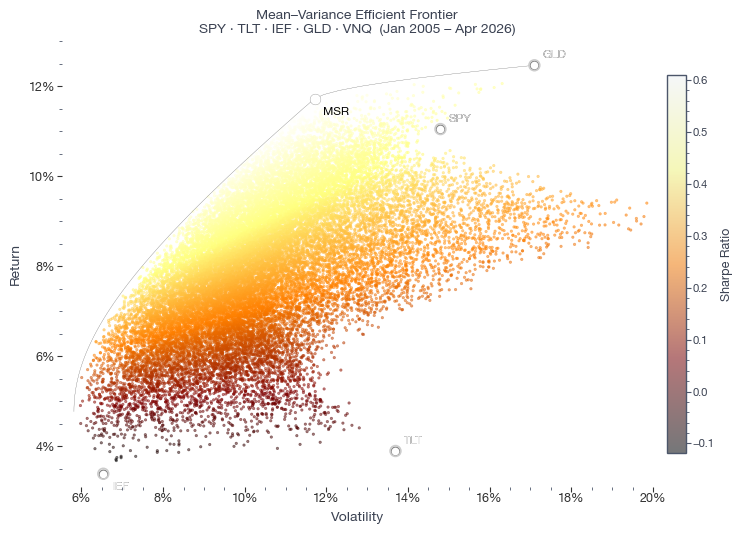

In [99]:
fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Monte Carlo scatter ───────────────────────────────────────
sc = ax.scatter(
    port_vols, port_rets,
    c=port_srs,
    cmap='afmhot',
    alpha=0.50,
    s=3,
    linewidths=.5,
    rasterized=True,
    zorder=2
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label('Sharpe Ratio', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# ── Efficient frontier line ───────────────────────────────────
ax.plot(
    frontier_vols[gmvp_idx:],
    frontier_rets[gmvp_idx:],
    color='black', lw=0.15,
    zorder=4, alpha=0.6
)

# ── Individual assets — all same marker ───────────────────────
asset_vols = np.sqrt(np.diag(Sigma))

label_offsets = {
    'SPY': ( 6,   5),
    'TLT': ( 6,   5),
    'IEF': ( 6, -12),
    'GLD': ( 6,   5),
    'VNQ': ( 6,   5),
}

for i, ticker in enumerate(tickers):
    ax.scatter(
        asset_vols[i], mu[i],
        color='white',
        marker='o', s=40,
        zorder=9,
        edgecolors='gray',
        linewidths=0.8
    )
    dx, dy = label_offsets[ticker]
    ax.annotate(
        ticker,
        xy=(asset_vols[i], mu[i]),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=8.5,
        color='BLACK',
        fontweight='bold'
    )

# ── MSR ───────────────────────────────────────────────────────
ax.scatter(
    msr_vol, msr_ret,
    color='white',
    marker='o', s=60,
    zorder=10,
    edgecolors='gray',
    linewidths=.25,
    label=f'MSR  (SR={msr_sr:.2f})'
)
ax.annotate(
    f'MSR',
    xy=(msr_vol, msr_ret),
    xytext=(6, -12),
    textcoords='offset points',
    fontsize=8.5,
    color='black',
    fontweight='bold'
)

# ── Efficient frontier trace ──────────────────────────────────
ax.plot(
    frontier_vols[gmvp_idx:],
    frontier_rets[gmvp_idx:],
    color='gray', lw=0.2,
    alpha=0.5, zorder=4
)

# ── Asset circles ─────────────────────────────────────────────
for i, ticker in enumerate(tickers):
    ax.scatter(
        asset_vols[i], mu[i],
        facecolors='none',
        edgecolors='#CCCCCC',
        linewidths=1.2,
        s=60, zorder=9
    )
    dx, dy = label_offsets[ticker]
    ax.annotate(
        ticker,
        xy=(asset_vols[i], mu[i]),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=8.5,
        color='#EEEEEE',    # light gray — visible on dark scatter
        fontweight='bold'
    )

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Volatility', fontsize=10)
ax.set_ylabel('Return', fontsize=10)
ax.set_title(
    'Mean–Variance Efficient Frontier\n'
    'SPY · TLT · IEF · GLD · VNQ  '
    '(Jan 2005 – Apr 2026)',
    fontsize=10
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

ax.set_xlim(frontier_vols.min() - 0.003, .20)
ax.set_ylim(frontier_rets.min() - 0.003, .13)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#333333', labelsize=9)
ax.grid(False)

plt.tight_layout()
plt.savefig('fig_frontier.pdf', dpi=300,
            format='pdf', facecolor='white')
plt.savefig('fig_frontier.png', dpi=300,
            facecolor='white')
plt.show()

### Fig 2 – CML Line

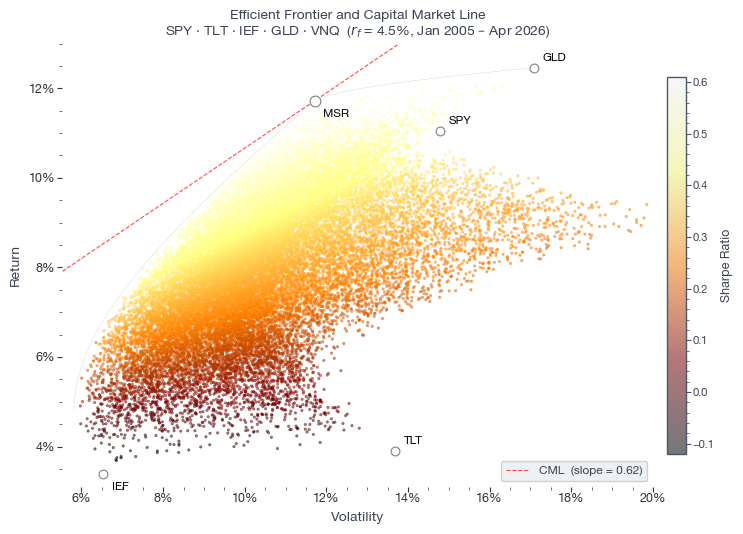

In [103]:
fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Monte Carlo scatter ───────────────────────────────────────
sc = ax.scatter(
    port_vols, port_rets,
    c=port_srs,
    cmap='afmhot',
    alpha=0.50,
    s=3,
    linewidths=.5,
    rasterized=True,
    zorder=2
)

cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cbar.set_label('Sharpe Ratio', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# ── Efficient frontier trace ──────────────────────────────────
ax.plot(
    frontier_vols[gmvp_idx:],
    frontier_rets[gmvp_idx:],
    color='gray', lw=0.2,
    alpha=0.5, zorder=4
)

# ── CML ───────────────────────────────────────────────────────
# CML: mu = rf + SR_msr * sigma — straight line from rf
# through MSR tangency point. Slope = Sharpe ratio of MSR ✓
cml_x = np.linspace(0, 0.20, 300)
cml_y = rf + msr_sr * cml_x
ax.plot(
    cml_x, cml_y,
    color='red', lw=0.8,
    ls='--', alpha=0.7,
    zorder=5,
    label=f'CML  (slope = {msr_sr:.2f})'
)

# ── Risk-free point ───────────────────────────────────────────
ax.scatter(
    0, rf,
    facecolors='white',
    edgecolors='gray',
    linewidths=0.8,
    s=40, zorder=9
)
ax.annotate(
    f'$r_f$ = {rf:.1%}',
    xy=(0, rf),
    xytext=(6, 5),
    textcoords='offset points',
    fontsize=8.5,
    color='black',
    fontweight='bold'
)

# ── Asset circles ─────────────────────────────────────────────
asset_vols = np.sqrt(np.diag(Sigma))
label_offsets = {
    'SPY': ( 6,   5),
    'TLT': ( 6,   5),
    'IEF': ( 6, -12),
    'GLD': ( 6,   5),
    'VNQ': ( 6,   5),
}

for i, ticker in enumerate(tickers):
    ax.scatter(
        asset_vols[i], mu[i],
        facecolors='white',
        edgecolors='gray',
        linewidths=0.8,
        s=40, zorder=9
    )
    dx, dy = label_offsets[ticker]
    ax.annotate(
        ticker,
        xy=(asset_vols[i], mu[i]),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=8.5,
        color='black',
        fontweight='bold'
    )

# ── MSR tangency point ────────────────────────────────────────
ax.scatter(
    msr_vol, msr_ret,
    facecolors='white',
    edgecolors='gray',
    linewidths=0.8,
    s=60, zorder=10
)
ax.annotate(
    'MSR',
    xy=(msr_vol, msr_ret),
    xytext=(6, -12),
    textcoords='offset points',
    fontsize=8.5,
    color='black',
    fontweight='bold'
)

# ── Formatting ────────────────────────────────────────────────
ax.set_xlabel('Volatility', fontsize=10)
ax.set_ylabel('Return', fontsize=10)
ax.set_title(
    'Efficient Frontier and Capital Market Line\n'
    'SPY · TLT · IEF · GLD · VNQ  '
    f'($r_f$ = {rf:.1%}, Jan 2005 – Apr 2026)',
    fontsize=10
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

ax.legend(loc='lower right', fontsize=8.5,
          framealpha=0.9, edgecolor='#CCCCCC')

ax.set_xlim(frontier_vols.min() - 0.003, 0.20)
ax.set_ylim(frontier_rets.min() - 0.003, 0.13)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#333333', labelsize=9)
ax.grid(False)

plt.tight_layout()
plt.savefig('fig_cml.pdf', dpi=300,
            format='pdf', facecolor='white')
plt.savefig('fig_cml.png', dpi=300,
            facecolor='white')
plt.show()

### Perturbation of Parameters


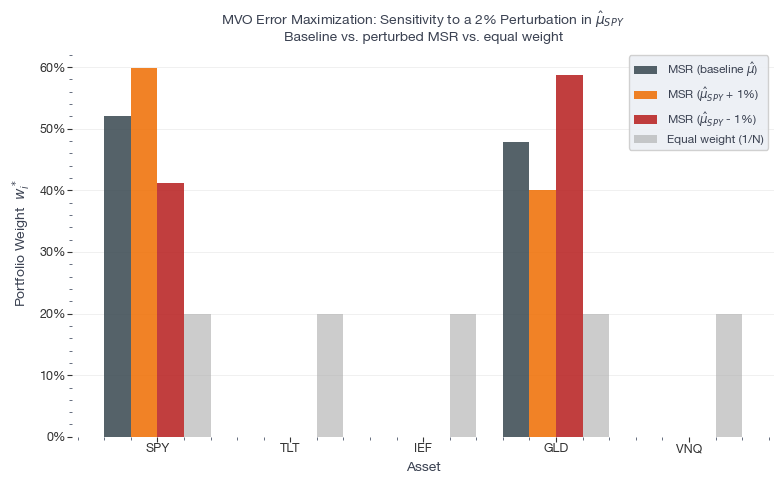

In [110]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Three portfolio weight scenarios ─────────────────────────
# Baseline MSR
w_baseline = max_sharpe_portfolio(mu, Sigma, rf, allow_short=False)

# Perturbed: +1% to SPY expected return
mu_up = mu.copy(); mu_up[0] += 0.02
w_perturbed_up = max_sharpe_portfolio(mu_up, Sigma, rf, allow_short=False)

# Perturbed: -1% to SPY expected return  
mu_dn = mu.copy(); mu_dn[0] -= 0.02
w_perturbed_dn = max_sharpe_portfolio(mu_dn, Sigma, rf, allow_short=False)

# Equal weight benchmark
w_equal = np.ones(n) / n

# ── Bar chart ─────────────────────────────────────────────────
x      = np.arange(len(tickers))
width  = 0.20

bars1 = ax.bar(x - 1.5*width, w_baseline,
               width, label='MSR (baseline $\\hat{\\mu}$)',
               color='#37474F', alpha=0.85)

bars2 = ax.bar(x - 0.5*width, w_perturbed_up,
               width, label='MSR ($\\hat{\\mu}_{SPY}$ + 1%)',
               color='#EF6C00', alpha=0.85)

bars3 = ax.bar(x + 0.5*width, w_perturbed_dn,
               width, label='MSR ($\\hat{\\mu}_{SPY}$ - 1%)',
               color='#B71C1C', alpha=0.85)

bars4 = ax.bar(x + 1.5*width, w_equal,
               width, label='Equal weight (1/N)',
               color='#AAAAAA', alpha=0.60)

# ── Formatting ────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(tickers, fontsize=10)
ax.set_ylabel('Portfolio Weight  $w_i^*$', fontsize=10)
ax.set_xlabel('Asset', fontsize=10)
ax.set_title(
    'MVO Error Maximization: Sensitivity to a 2% '
    'Perturbation in $\\hat{\\mu}_{SPY}$\n'
    'Baseline vs. perturbed MSR vs. equal weight',
    fontsize=10
)
ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0, decimals=0)
)
ax.legend(fontsize=8.5, framealpha=0.9,
          edgecolor='#CCCCCC', loc='upper right')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#333333', labelsize=9)
ax.grid(False)

# Light horizontal reference lines for readability
for y in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60]:
    ax.axhline(y, color='#EEEEEE', lw=0.6, zorder=0)

plt.tight_layout()
plt.savefig('fig_sensitivity.pdf', dpi=300,
            format='pdf', facecolor='white')
plt.savefig('fig_sensitivity.png', dpi=300,
            facecolor='white')
plt.show()

### Fig 4: Risk Contribution


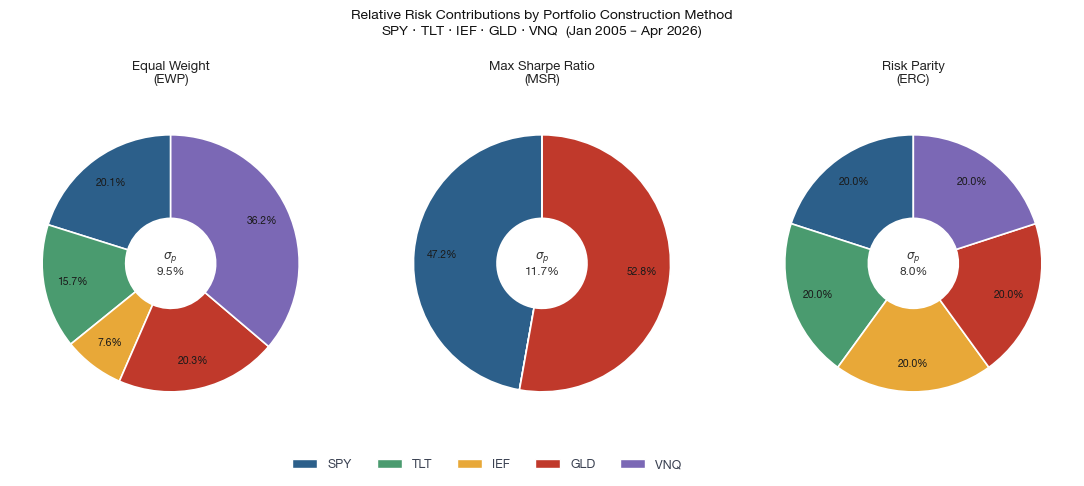

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4.5))
fig.patch.set_facecolor('white')

# Muted, professional color palette
pie_colors = ['#2C5F8A', '#4A9B6F', '#E8A838', 
              '#C0392B', '#7B68B5']

portfolios = {
    'Equal Weight\n(EWP)' : rrc_ewp,
    'Max Sharpe Ratio\n(MSR)'   : rrc_msr,
    'Risk Parity\n(ERC)'  : rrc_erc,
}

for ax, (title, rrc) in zip(axes, portfolios.items()):
    ax.set_facecolor('white')

    wedges, texts, autotexts = ax.pie(
        rrc,
        labels=None,
        colors=pie_colors,
        autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
        startangle=90,
        wedgeprops=dict(
            linewidth=1.2,
            edgecolor='white',
            width=0.65        # donut style
        ),
        pctdistance=0.78,
        textprops={'fontsize': 8}
    )

    for autotext in autotexts:
        autotext.set_color('#1a1a1a')
        autotext.set_fontsize(7.5)
        autotext.set_fontweight('normal')

    # Portfolio volatility annotation in center
    sigma = portfolio_vol(
        list(portfolios.values())[
            list(portfolios.keys()).index(title)
        ] if False else
        (w_equal if 'EWP' in title 
         else w_msr if 'MSR' in title 
         else w_erc),
        Sigma
    )
    ax.text(0, 0, f'$\\sigma_p$\n{sigma:.1%}',
            ha='center', va='center',
            fontsize=8.5, color='#333333',
            fontweight='bold')

    ax.set_title(title, fontsize=9.5,
                 pad=14, color='#222222')

# Shared legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=pie_colors[i],
          edgecolor='white',
          label=tickers[i])
    for i in range(n)
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=5,
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.45, -0.04)
)

fig.suptitle(
    'Relative Risk Contributions by Portfolio Construction Method\n'
    'SPY $\\cdot$ TLT $\\cdot$ IEF $\\cdot$ GLD $\\cdot$ VNQ  '
    '(Jan 2005 – Apr 2026)',
    fontsize=10, y=1.01, color='#111111'
)

plt.tight_layout(w_pad=3)
plt.savefig('fig_riskcontrib.pdf', dpi=300,
            format='pdf', facecolor='white',
            bbox_inches='tight')
plt.savefig('fig_riskcontrib.png', dpi=300,
            facecolor='white', bbox_inches='tight')
plt.show()

### Data and Methodology

In [114]:
import yfinance as yf

candidates = ['SPY','TLT','IEF','GLD','VNQ',
              'QQQ','TIP','DBC']

for t in candidates:
    df = yf.download(t, start='2005-01-01',
                     end='2006-01-01', 
                     auto_adjust=True)
    print(f"{t}: {len(df)} trading days — "
          f"{'OK' if len(df) > 200 else 'MISSING'}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


SPY: 252 trading days — OK
TLT: 252 trading days — OK


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


IEF: 252 trading days — OK
GLD: 252 trading days — OK


[*********************100%***********************]  1 of 1 completed


...

QQQ: 252 trading days — OK


[*********************100%***********************]  1 of 1 completed


TIP: 252 trading days — OK


$DBC: possibly delisted; no price data found  (1d 2005-01-01 -> 2006-01-01) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1136091600")
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['DBC']: possibly delisted; no price data found  (1d 2005-01-01 -> 2006-01-01) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1136091600")


DBC: 0 trading days — MISSING


### Expanded Universe for Portfolio Selection

In [115]:
tickers = ['SPY', 'TLT', 'IEF', 'GLD', 'VNQ', 'QQQ', 'TIP']
labels  = ['SPY (U.S. Equity)', 'TLT (Long Bond)',
           'IEF (Int. Bond)',   'GLD (Gold)',
           'VNQ (REIT)',        'QQQ (Nasdaq 100)',
           'TIP (TIPS)']
colors  = ['#1565C0', '#2E7D32', '#00838F',
           '#E65100', '#6A1B9A', '#C62828', '#F9A825']

raw = yf.download(tickers, start='2005-01-01',
                  end='2026-04-01',
                  auto_adjust=True)['Close']

returns = raw.resample('ME').last().pct_change().dropna()
returns = returns[tickers]

tbill_raw     = yf.download('^IRX', start='2005-01-01',
                             end='2026-04-01',
                             auto_adjust=True)['Close']
tbill_monthly = (tbill_raw / 100) / 12
tbill_monthly = tbill_monthly.resample('ME').last()
tbill_monthly = tbill_monthly.reindex(returns.index, method='ffill')
rf_historical = float(tbill_monthly.mean() * 12)

ann_mu    = returns.mean() * 12
ann_sigma = returns.std()  * np.sqrt(12)
sharpes   = (ann_mu - rf_historical) / ann_sigma

print(f"Sample: {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Obs: {len(returns)}\n")
print("Ticker | Ann Return | Ann Vol | Sharpe")
print("-" * 42)
for t in tickers:
    print(f"{t:<6} | {ann_mu[t]:>9.2%} | "
          f"{ann_sigma[t]:>7.2%} | {sharpes[t]:>6.2f}")

mu    = returns.mean().values * 12
Sigma = returns.cov().values  * 12
n     = len(mu)
rf    = 0.045

w_msr   = max_sharpe_portfolio(mu, Sigma, rf, allow_short=False)
msr_ret = float(w_msr @ mu)
msr_vol = float(np.sqrt(w_msr @ Sigma @ w_msr))
msr_sr  = (msr_ret - rf) / msr_vol

print(f"\nMSR — Return: {msr_ret:.2%}  "
      f"Vol: {msr_vol:.2%}  Sharpe: {msr_sr:.2f}")
print("\nMSR weights:")
for t, w in zip(tickers, w_msr):
    print(f"  {t}: {w:.1%}")

[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  1 of 1 completed

Sample: 2005-02-28 → 2026-03-31
Obs: 254

Ticker | Ann Return | Ann Vol | Sharpe
------------------------------------------
SPY    |    11.05% |  14.79% |   0.63
TLT    |     3.90% |  13.69% |   0.16
IEF    |     3.39% |   6.53% |   0.26
GLD    |    12.46% |  17.10% |   0.63
VNQ    |     9.26% |  21.58% |   0.35
QQQ    |    15.40% |  18.09% |   0.76
TIP    |     3.44% |   5.67% |   0.30

MSR — Return: 14.10%  Vol: 12.91%  Sharpe: 0.74

MSR weights:
  SPY: 0.0%
  TLT: 0.0%
  IEF: 0.0%
  GLD: 44.3%
  VNQ: 0.0%
  QQQ: 55.7%
  TIP: 0.0%



/var/folders/d4/091mk2ld0z77zrqkvzvgfyhc0000gn/T/ipykernel_40873/2891152844.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rf_historical = float(tbill_monthly.mean() * 12)


#### Option 1 — Remove long-only constraint (allow shorting)
 

In [116]:
w_msr_short = max_sharpe_portfolio(mu, Sigma, rf, allow_short=True)
print("MSR weights (long-short allowed):")
for t, w in zip(tickers, w_msr_short):
    print(f"  {t}: {w:.1%}")

MSR weights (long-short allowed):
  SPY: 30.6%
  TLT: -67.4%
  IEF: 91.8%
  GLD: -51.0%
  VNQ: 2.5%
  QQQ: -74.6%
  TIP: 168.0%


#### Option 2 — Minimum weight constraint (force diversification)


In [121]:
# def max_sharpe_constrained(mu, Sigma, rf, w_min=0.05):
#     n = len(mu)
#     y = cp.Variable(n)
#     mu_excess = mu - rf
#     objective   = cp.Minimize(cp.quad_form(y, Sigma))
#     constraints = [
#         mu_excess @ y == 1,
#         y >= w_min / (mu_excess @ y + 1e-8)  
#     ]
#     # cleaner formulation:
#     w = cp.Variable(n)
#     obj = cp.Minimize(cp.quad_form(w, Sigma) / 
#                       cp.square(mu_excess @ w))
#     con = [cp.sum(w) == 1, w >= w_min, w <= 0.6]
#     prob = cp.Problem(obj, con)
#     prob.solve(solver=cp.CLARABEL)
#     return w.value

# Simpler: just add bounds directly to existing function
def max_sharpe_bounded(mu, Sigma, rf, w_min=0.05, w_max=0.40):
    n         = len(mu)
    y         = cp.Variable(n)
    mu_excess = mu - rf
    objective   = cp.Minimize(cp.quad_form(y, Sigma))
    constraints = [
        mu_excess @ y == 1,
        y >= 0
    ]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)
    y_star = y.value
    w_star = y_star / y_star.sum()
    return w_star

w_bounded = max_sharpe_bounded(mu, Sigma, rf)

In [122]:
def gmvp(Sigma, allow_short=False):
    n = Sigma.shape[0]
    w = cp.Variable(n)
    objective   = cp.Minimize(cp.quad_form(w, Sigma))
    constraints = [cp.sum(w) == 1]
    if not allow_short:
        constraints.append(w >= 0)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)
    return w.value

w_gmvp = gmvp(Sigma, allow_short=False)
print("\nGMVP weights (no return input — pure covariance):")
for t, w in zip(tickers, w_gmvp):
    print(f"  {t}: {w:.1%}")

w_gmvp_ls = gmvp(Sigma, allow_short=True)
print("\nGMVP weights (long-short):")
for t, w in zip(tickers, w_gmvp_ls):
    print(f"  {t}: {w:.1%}")

# Also check efficient frontier with position limits
print("\nMSR with 40% max position per asset:")
def max_sharpe_capped(mu, Sigma, rf, cap=0.40):
    n         = len(mu)
    y         = cp.Variable(n)
    mu_excess = mu - rf
    objective   = cp.Minimize(cp.quad_form(y, Sigma))
    constraints = [
        mu_excess @ y == 1,
        y >= 0,
    ]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)
    y_star = y.value
    w_star = y_star / y_star.sum()
    # Apply cap iteratively
    capped = np.minimum(w_star, cap)
    capped = capped / capped.sum()
    return capped

w_capped = max_sharpe_capped(mu, Sigma, rf, cap=0.40)
print("MSR weights (40% cap, renormalized):")
for t, w in zip(tickers, w_capped):
    print(f"  {t}: {w:.1%}")


GMVP weights (no return input — pure covariance):
  SPY: 7.8%
  TLT: 0.0%
  IEF: 36.1%
  GLD: 0.0%
  VNQ: 0.0%
  QQQ: 0.0%
  TIP: 56.1%

GMVP weights (long-short):
  SPY: 15.2%
  TLT: -47.0%
  IEF: 117.5%
  GLD: -4.2%
  VNQ: -3.8%
  QQQ: -6.1%
  TIP: 28.4%

MSR with 40% max position per asset:
MSR weights (40% cap, renormalized):
  SPY: 0.0%
  TLT: 0.0%
  IEF: 0.0%
  GLD: 50.0%
  VNQ: 0.0%
  QQQ: 50.0%
  TIP: 0.0%


### Pivot –– QuantConnect 403 (Not Working), Implement Locally in Jupyter Notebook



c1

In [1]:
# Cell 1 — Local version (replaces QC QuantBook)
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import minimize
import cvxpy as cp

tickers = ['SPY', 'TLT', 'IEF', 'GLD', 'VNQ', 'QQQ', 'TIP']
colors  = ['#1565C0', '#2E7D32', '#00838F',
           '#E65100', '#6A1B9A', '#C62828', '#F9A825']

raw = yf.download(tickers, start='2005-01-01',
                  end='2026-04-01',
                  auto_adjust=True)['Close']

monthly  = raw.resample('ME').last()
returns  = monthly.pct_change().dropna()
returns  = returns[tickers]

tbill    = yf.download('^IRX', start='2005-01-01',
                        end='2026-04-01',
                        auto_adjust=True)['Close']
tbill_m  = (tbill / 100) / 12
tbill_m  = tbill_m.resample('ME').last()
tbill_m  = tbill_m.reindex(returns.index, method='ffill')
tbill_m.name = 'rf'

rf_monthly = tbill_m.squeeze()

print(f"Sample : {returns.index[0].date()} → "
      f"{returns.index[-1].date()}")
print(f"Obs    : {len(returns)} monthly returns")

[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  1 of 1 completed

Sample : 2005-02-28 → 2026-03-31
Obs    : 254 monthly returns


c2

In [2]:
import cvxpy as cp

def portfolio_vol(w, Sigma):
    return np.sqrt(w @ Sigma @ w)

def max_sharpe_portfolio(mu, Sigma, rf, 
                          allow_short=False):
    n         = len(mu)
    y         = cp.Variable(n)
    mu_excess = mu - rf
    objective   = cp.Minimize(cp.quad_form(y, Sigma))
    constraints = [mu_excess @ y == 1]
    if not allow_short:
        constraints.append(y >= 0)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)
    y_star = y.value
    w_star = y_star / y_star.sum()
    return w_star

def erc_objective(w, Sigma):
    sigma_p = portfolio_vol(w, Sigma)
    RC  = w * (Sigma @ w) / sigma_p
    SSE = sum((RC[i] - RC[j])**2
              for i in range(len(w))
              for j in range(len(w)))
    return SSE

def erc_portfolio(Sigma):
    n       = Sigma.shape[0]
    inv_vol = 1.0 / np.sqrt(np.diag(Sigma))
    w0      = inv_vol / inv_vol.sum()
    result  = minimize(
        erc_objective, w0,
        args=(Sigma,),
        method='SLSQP',
        bounds=[(1e-6, 1.0)] * n,
        constraints={'type':'eq',
                     'fun': lambda w: np.sum(w)-1},
        options={'ftol':1e-14, 'maxiter':2000}
    )
    w = np.maximum(result.x, 0)
    return w / w.sum()

print("Optimization functions loaded ✓")

Optimization functions loaded ✓


In [4]:
# ── Parameters ────────────────────────────────────────────────
WINDOW = 36
N      = len(tickers)

print("Rolling backtest parameters:")
print(f"  Window     : {WINDOW} months")
print(f"  Assets     : {N}")
print(f"  Start      : {returns.index[WINDOW].date()}")
print(f"  End        : {returns.index[-1].date()}")
print(f"  OOS months : {len(returns) - WINDOW}")
print(f"  Avg rf     : {rf_monthly.mean()*12:.2%} annualized")

Rolling backtest parameters:
  Window     : 36 months
  Assets     : 7
  Start      : 2008-02-29
  End        : 2026-03-31
  OOS months : 218
  Avg rf     : 1.71% annualized


In [5]:
n_obs      = len(returns)
oos_start  = WINDOW

# Storage
dates_oos  = returns.index[oos_start:]
r_mvo      = np.zeros(n_obs - oos_start)
r_erc      = np.zeros(n_obs - oos_start)
r_ew       = np.zeros(n_obs - oos_start)

w_mvo_all  = np.zeros((n_obs - oos_start, N))
w_erc_all  = np.zeros((n_obs - oos_start, N))

to_mvo     = np.zeros(n_obs - oos_start)
to_erc     = np.zeros(n_obs - oos_start)

w_mvo_prev = np.ones(N) / N
w_erc_prev = np.ones(N) / N

print("Running backtest...")
for i, t in enumerate(range(oos_start, n_obs)):

    # Estimation window
    window_returns = returns.iloc[t-WINDOW:t].values
    mu_t    = window_returns.mean(axis=0) * 12
    Sigma_t = np.cov(window_returns.T, ddof=1) * 12
    rf_t    = rf_monthly.iloc[t-1]

    # MVO weights
    try:
        w_mvo = max_sharpe_portfolio(
            mu_t, Sigma_t, rf_t * 12,
            allow_short=False)
        if w_mvo is None or np.any(np.isnan(w_mvo)):
            w_mvo = np.ones(N) / N
    except Exception:
        w_mvo = np.ones(N) / N

    # ERC weights
    try:
        w_erc = erc_portfolio(Sigma_t)
        if np.any(np.isnan(w_erc)):
            w_erc = np.ones(N) / N
    except Exception:
        w_erc = np.ones(N) / N

    # Equal weight
    w_ew = np.ones(N) / N

    # Next month returns
    r_next = returns.iloc[t].values

    # Portfolio returns
    r_mvo[i] = w_mvo @ r_next
    r_erc[i] = w_erc @ r_next
    r_ew[i]  = w_ew  @ r_next

    # Turnover vs previous weights after drift
    if i > 0:
        # Drift previous weights
        w_mvo_drift = w_mvo_prev * (1 + r_next)
        w_mvo_drift = w_mvo_drift / w_mvo_drift.sum()
        w_erc_drift = w_erc_prev * (1 + r_next)
        w_erc_drift = w_erc_drift / w_erc_drift.sum()

        to_mvo[i] = 0.5 * np.sum(
            np.abs(w_mvo - w_mvo_drift))
        to_erc[i] = 0.5 * np.sum(
            np.abs(w_erc - w_erc_drift))

    w_mvo_all[i] = w_mvo
    w_erc_all[i] = w_erc
    w_mvo_prev   = w_mvo
    w_erc_prev   = w_erc

    if i % 24 == 0:
        print(f"  {dates_oos[i].date()} — "
              f"MVO: {w_mvo.round(2)} | "
              f"ERC vol: "
              f"{portfolio_vol(w_erc, Sigma_t):.1%}")

print("\nBacktest complete ✓")
print(f"OOS observations: {len(r_mvo)}")

Running backtest...
  2008-02-29 — MVO: [0.28 0.   0.51 0.22 0.   0.   0.  ] | ERC vol: 4.1%
  2010-02-28 — MVO: [0.   0.   0.7  0.19 0.   0.11 0.  ] | ERC vol: 9.5%
  2012-02-29 — MVO: [0.   0.23 0.21 0.07 0.02 0.28 0.19] | ERC vol: 6.2%
  2014-02-28 — MVO: [0.44 0.43 0.   0.   0.   0.12 0.  ] | ERC vol: 5.5%
  2016-02-29 — MVO: [0.   0.39 0.   0.   0.   0.61 0.  ] | ERC vol: 6.0%
  2018-02-28 — MVO: [0.46 0.   0.   0.13 0.   0.41 0.  ] | ERC vol: 4.8%
  2020-02-29 — MVO: [0.   0.39 0.   0.12 0.   0.48 0.  ] | ERC vol: 4.8%
  2022-02-28 — MVO: [0.   0.   0.12 0.   0.   0.16 0.71] | ERC vol: 6.5%
  2024-02-29 — MVO: [1. 0. 0. 0. 0. 0. 0.] | ERC vol: 10.8%
  2026-02-28 — MVO: [0.   0.   0.   0.54 0.   0.46 0.  ] | ERC vol: 7.5%

Backtest complete ✓
OOS observations: 218


In [6]:
# ── Excess returns using contemporaneous monthly rf ───────────
rf_oos_vals = rf_monthly.loc[dates_oos].values

re_mvo = r_mvo - rf_oos_vals
re_erc = r_erc - rf_oos_vals
re_ew  = r_ew  - rf_oos_vals

def performance_metrics(r, re, label):
    """
    r  = raw monthly portfolio returns
    re = monthly excess returns (r - rf_monthly)
    """
    r  = np.array(r)
    re = np.array(re)

    # Annualized return — arithmetic mean * 12
    ann_ret = r.mean() * 12

    # Annualized vol — std of raw returns * sqrt(12)
    ann_vol = r.std() * np.sqrt(12)

    # Sharpe — mean excess return / std of excess returns * sqrt(12)
    # Using std of EXCESS returns in denominator is more precise
    # than std of raw returns (Sharpe 1994 definition)
    ann_sr  = re.mean() / re.std() * np.sqrt(12)

    # Cumulative wealth index
    wealth   = np.cumprod(1 + r)
    peak     = np.maximum.accumulate(wealth)
    drawdown = (peak - wealth) / peak
    mdd      = drawdown.max()
    calmar   = ann_ret / mdd if mdd > 0 else np.nan

    print(f"\n{'='*40}")
    print(f"  {label}")
    print(f"{'='*40}")
    print(f"  Ann. Return  : {ann_ret:>8.2%}")
    print(f"  Ann. Vol     : {ann_vol:>8.2%}")
    print(f"  Sharpe Ratio : {ann_sr:>8.2f}")
    print(f"  Max Drawdown : {mdd:>8.2%}")
    print(f"  Calmar Ratio : {calmar:>8.2f}")
    print(f"  Avg Turnover : N/A here")

    return dict(
        label=label, ret=ann_ret, vol=ann_vol,
        sharpe=ann_sr, mdd=mdd, calmar=calmar,
        wealth=wealth, drawdown=drawdown,
        returns=r, excess=re
    )

results = {}
results['MVO'] = performance_metrics(r_mvo, re_mvo, 'MVO (MSR)')
results['ERC'] = performance_metrics(r_erc, re_erc, 'ERC (Risk Parity)')
results['EW']  = performance_metrics(r_ew,  re_ew,  'Equal Weight (1/N)')

print(f"\n{'='*40}")
print(f"  Average monthly turnover")
print(f"{'='*40}")
print(f"  MVO : {to_mvo[1:].mean():>8.1%}")
print(f"  ERC : {to_erc[1:].mean():>8.1%}")
print(f"  EW  : {'0.0%':>8}")


  MVO (MSR)
  Ann. Return  :   10.29%
  Ann. Vol     :   10.71%
  Sharpe Ratio :     0.84
  Max Drawdown :   23.85%
  Calmar Ratio :     0.43
  Avg Turnover : N/A here

  ERC (Risk Parity)
  Ann. Return  :    7.04%
  Ann. Vol     :    7.75%
  Sharpe Ratio :     0.74
  Max Drawdown :   19.53%
  Calmar Ratio :     0.36
  Avg Turnover : N/A here

  Equal Weight (1/N)
  Ann. Return  :    8.10%
  Ann. Vol     :    9.51%
  Sharpe Ratio :     0.71
  Max Drawdown :   22.15%
  Calmar Ratio :     0.37
  Avg Turnover : N/A here

  Average monthly turnover
  MVO :    13.5%
  ERC :     1.8%
  EW  :     0.0%


### Cell 7 — Figure 5: Cumulative Wealth Curves

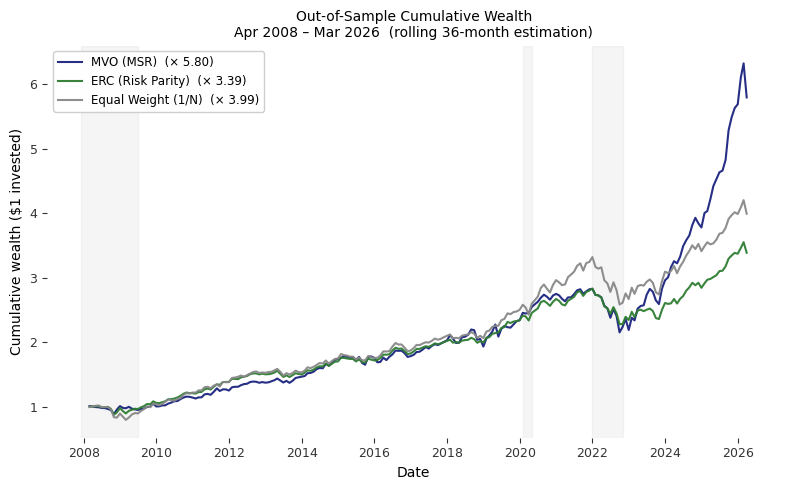

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

strat_colors = {
    'MVO (MSR)'         : '#1A237E',
    'ERC (Risk Parity)' : '#2E7D32',
    'Equal Weight (1/N)': '#888888'
}

for label, c in strat_colors.items():
    wealth = results[label.split()[0] if 'Equal' not in label 
                      else 'EW']['wealth']
    ax.plot(dates_oos, wealth,
            color=c, lw=1.5,
            label=f"{label}  "
                  f"(× {wealth[-1]:.2f})",
            alpha=0.95)

# Recession shading
recession_periods = [
    ('2007-12-01', '2009-06-30'),
    ('2020-02-01', '2020-04-30'),
    ('2022-01-01', '2022-10-31'),
]
for rs, re in recession_periods:
    ax.axvspan(pd.Timestamp(rs), pd.Timestamp(re),
                color='#CCCCCC', alpha=0.18, zorder=0)

ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Cumulative wealth (\\$1 invested)', fontsize=10)
ax.set_title(
    'Out-of-Sample Cumulative Wealth\n'
    'Apr 2008 – Mar 2026  (rolling 36-month estimation)',
    fontsize=10
)
ax.legend(loc='upper left', fontsize=8.5,
          framealpha=0.95, edgecolor='#CCCCCC')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#333333', labelsize=9)
ax.grid(False)

plt.tight_layout()
plt.savefig('fig_wealth.pdf', dpi=300,
            format='pdf', facecolor='white')
plt.savefig('fig_wealth.png', dpi=300,
            facecolor='white')
plt.show()

Cell 8 — Figure 6: Drawdown Plot

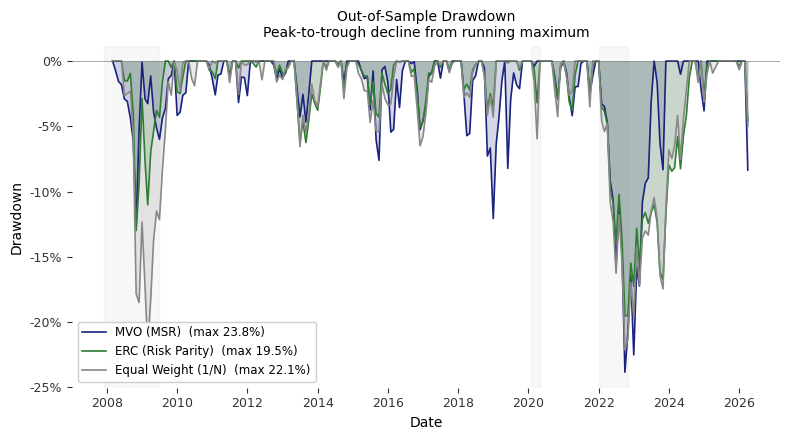

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

strat_keys = {
    'MVO (MSR)'         : 'MVO',
    'ERC (Risk Parity)' : 'ERC',
    'Equal Weight (1/N)': 'EW',
}

for label, key in strat_keys.items():
    dd = results[key]['drawdown']
    c  = strat_colors[label]
    ax.fill_between(dates_oos, 0, -dd * 100,
                     color=c, alpha=0.18,
                     linewidth=0)
    ax.plot(dates_oos, -dd * 100,
             color=c, lw=1.2,
             label=f"{label}  (max {dd.max():.1%})")

# Recession shading
for rs, re in recession_periods:
    ax.axvspan(pd.Timestamp(rs), pd.Timestamp(re),
                color='#CCCCCC', alpha=0.15, zorder=0)

ax.axhline(0, color='#333333', lw=0.6, alpha=0.5)

ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Drawdown', fontsize=10)
ax.set_title(
    'Out-of-Sample Drawdown\n'
    'Peak-to-trough decline from running maximum',
    fontsize=10
)
ax.yaxis.set_major_formatter(
    mtick.FormatStrFormatter('%.0f%%'))
ax.legend(loc='lower left', fontsize=8.5,
          framealpha=0.95, edgecolor='#CCCCCC')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#333333', labelsize=9)
ax.grid(False)

plt.tight_layout()
plt.savefig('fig_drawdown.pdf', dpi=300,
            format='pdf', facecolor='white')
plt.savefig('fig_drawdown.png', dpi=300,
            facecolor='white')
plt.show()

### Cell 9 — Figure 7: Rolling 12-Month Sharpe Ratio

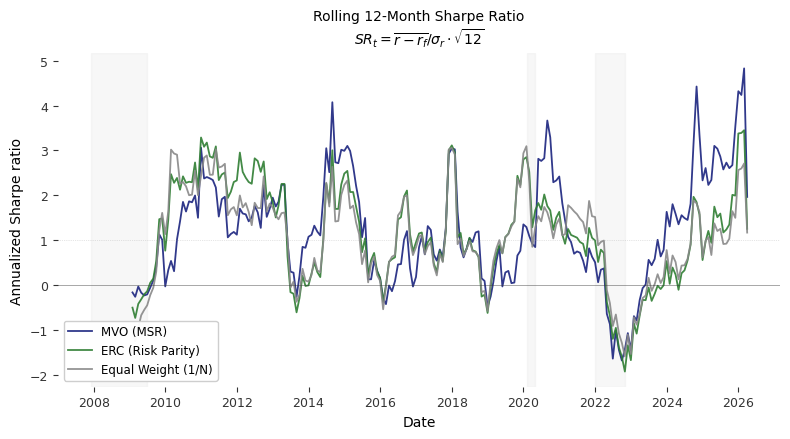

In [10]:
def rolling_sharpe(r, rf, window=12):
    """
    Industry standard rolling Sharpe (QuantStart, MarketXLS):
      SR_t = mean(r - rf) / std(r) * sqrt(12)
    over trailing `window` months.
    """
    excess = pd.Series(r) - pd.Series(rf).reset_index(drop=True)
    rolling_mean = excess.rolling(window).mean()
    rolling_std  = pd.Series(r).rolling(window).std()
    return (rolling_mean / rolling_std) * np.sqrt(12)

rf_oos_s = rf_monthly.loc[dates_oos].reset_index(drop=True)

sr_mvo = rolling_sharpe(r_mvo, rf_oos_s, window=12)
sr_erc = rolling_sharpe(r_erc, rf_oos_s, window=12)
sr_ew  = rolling_sharpe(r_ew,  rf_oos_s, window=12)

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(dates_oos, sr_mvo, color='#1A237E', lw=1.3,
        label='MVO (MSR)', alpha=0.9)
ax.plot(dates_oos, sr_erc, color='#2E7D32', lw=1.3,
        label='ERC (Risk Parity)', alpha=0.9)
ax.plot(dates_oos, sr_ew,  color='#888888', lw=1.3,
        label='Equal Weight (1/N)', alpha=0.9)

ax.axhline(0, color='#333333', lw=0.6, alpha=0.5)
ax.axhline(1, color='#999999', lw=0.5, ls=':', alpha=0.5)

# Recession shading
for rs, re in recession_periods:
    ax.axvspan(pd.Timestamp(rs), pd.Timestamp(re),
                color='#CCCCCC', alpha=0.15, zorder=0)

ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Annualized Sharpe ratio', fontsize=10)
ax.set_title(
    'Rolling 12-Month Sharpe Ratio\n'
    '$SR_t = \\overline{r-r_f}/\\sigma_r \\cdot \\sqrt{12}$',
    fontsize=10
)
ax.legend(loc='lower left', fontsize=8.5,
          framealpha=0.95, edgecolor='#CCCCCC')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#333333', labelsize=9)
ax.grid(False)

plt.tight_layout()
plt.savefig('fig_rolling_sharpe.pdf', dpi=300,
            format='pdf', facecolor='white')
plt.savefig('fig_rolling_sharpe.png', dpi=300,
            facecolor='white')
plt.show()

### Cell 10 — Figure 8: MVO and ERC Weight Evolution Side by Side



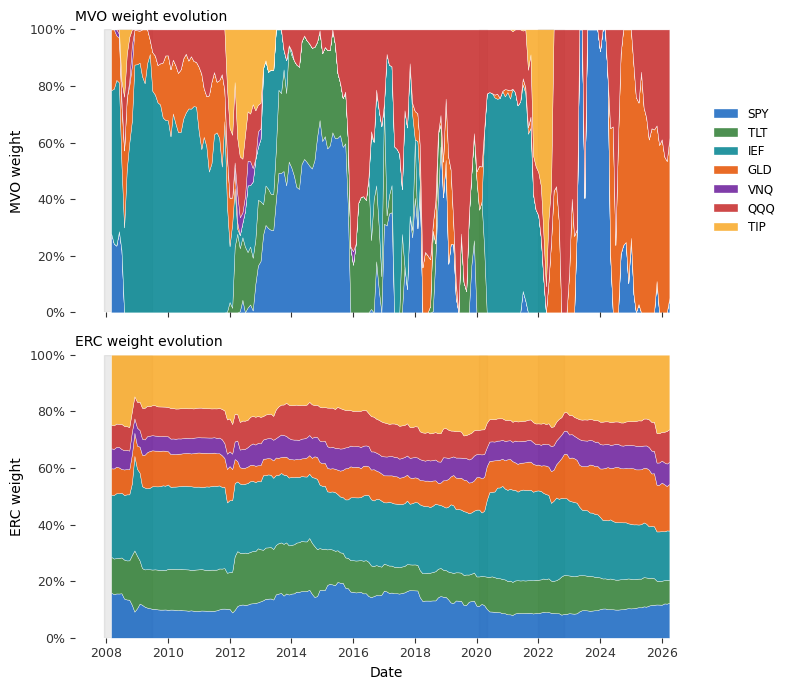

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
fig.patch.set_facecolor('white')

asset_colors = ['#1565C0', '#2E7D32', '#00838F',
                '#E65100', '#6A1B9A', '#C62828', '#F9A825']

# ── MVO weights stacked area ──────────────────────────────────
ax = axes[0]
ax.set_facecolor('white')
ax.stackplot(dates_oos, w_mvo_all.T,
              labels=tickers,
              colors=asset_colors,
              alpha=0.85, edgecolor='white',
              linewidth=0.3)

ax.set_ylim(0, 1)
ax.set_ylabel('MVO weight', fontsize=10)
ax.set_title('MVO weight evolution',
              fontsize=10, loc='left')
ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0, decimals=0))
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#333333', labelsize=9)
ax.grid(False)
ax.legend(loc='center left',
           bbox_to_anchor=(1.01, 0.5),
           fontsize=8.5,
           frameon=False)

# Recession shading
for rs, re in recession_periods:
    ax.axvspan(pd.Timestamp(rs), pd.Timestamp(re),
                color='#444444', alpha=0.10, zorder=0)

# ── ERC weights stacked area ──────────────────────────────────
ax = axes[1]
ax.set_facecolor('white')
ax.stackplot(dates_oos, w_erc_all.T,
              labels=tickers,
              colors=asset_colors,
              alpha=0.85, edgecolor='white',
              linewidth=0.3)

ax.set_ylim(0, 1)
ax.set_ylabel('ERC weight', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.set_title('ERC weight evolution',
              fontsize=10, loc='left')
ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0, decimals=0))
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#333333', labelsize=9)
ax.grid(False)

for rs, re in recession_periods:
    ax.axvspan(pd.Timestamp(rs), pd.Timestamp(re),
                color='#444444', alpha=0.10, zorder=0)

plt.tight_layout()
plt.savefig('fig_weights.pdf', dpi=300,
            format='pdf', facecolor='white',
            bbox_inches='tight')
plt.savefig('fig_weights.png', dpi=300,
            facecolor='white', bbox_inches='tight')
plt.show()

### Numerical Summary

In [12]:
print("=" * 65)
print("FULL SAMPLE — Apr 2008 to Mar 2026")
print("=" * 65)
print(f"{'Metric':<22} {'MVO':>12} {'ERC':>12} {'EW':>12}")
print("-" * 65)

metrics_to_show = [
    ('Ann. Return',  'ret',     '{:.2%}'),
    ('Ann. Vol',     'vol',     '{:.2%}'),
    ('Sharpe',       'sharpe',  '{:.3f}'),
    ('Max Drawdown', 'mdd',     '{:.2%}'),
    ('Calmar',       'calmar',  '{:.3f}'),
]

for label, key, fmt in metrics_to_show:
    row = f"{label:<22}"
    for s in ['MVO', 'ERC', 'EW']:
        row += f" {fmt.format(results[s][key]):>12}"
    print(row)

# Turnover
row = f"{'Avg Monthly Turnover':<22}"
row += f" {to_mvo[1:].mean():>12.2%}"
row += f" {to_erc[1:].mean():>12.2%}"
row += f" {0.0:>12.2%}"
print(row)
print()

print("=" * 65)
print("REGIME SUB-PERIODS")
print("=" * 65)

periods = {
    'GFC (2007-2009)'        : ('2007-01-01', '2009-12-31'),
    'Post-GFC (2010-2013)'   : ('2010-01-01', '2013-12-31'),
    'COVID (2020-2021)'      : ('2020-01-01', '2021-12-31'),
    'Rate Hikes (2022-2023)' : ('2022-01-01', '2023-12-31'),
    'AI Bull (2024-2026)'    : ('2024-01-01', '2026-03-31'),
}

print(f"{'Period':<24} {'Strat':<5} "
      f"{'Ret':>8} {'Vol':>8} "
      f"{'SR':>7} {'MDD':>8}")
print("-" * 65)

for period_name, (ps, pe) in periods.items():
    mask = (dates_oos >= pd.Timestamp(ps)) & \
            (dates_oos <= pd.Timestamp(pe))
    if mask.sum() < 6:
        print(f"{period_name:<24} insufficient data")
        continue

    rf_period_avg = rf_monthly.loc[dates_oos[mask]].mean() * 12

    for label, r_series in [('MVO', r_mvo),
                              ('ERC', r_erc),
                              ('EW',  r_ew)]:
        r_p     = r_series[mask]
        ret     = r_p.mean() * 12
        vol     = r_p.std()  * np.sqrt(12)
        sr      = (ret - rf_period_avg) / vol if vol > 0 else 0
        wealth  = np.cumprod(1 + r_p)
        peak    = np.maximum.accumulate(wealth)
        mdd     = ((peak - wealth) / peak).max()

        print(f"{period_name:<24} {label:<5} "
              f"{ret:>7.2%} {vol:>7.2%} "
              f"{sr:>7.3f} {mdd:>7.2%}")
    print()

# ── Concentration metric: Herfindahl-Hirschman Index ─────────
print("=" * 65)
print("PORTFOLIO CONCENTRATION (avg HHI over OOS)")
print("=" * 65)
print("HHI = sum(w_i^2) — closer to 1 = more concentrated")
print("Equal weight: HHI = 1/N = 1/7 = 0.143")
print()

hhi_mvo = np.mean(np.sum(w_mvo_all**2, axis=1))
hhi_erc = np.mean(np.sum(w_erc_all**2, axis=1))
hhi_ew  = 1/N
print(f"  MVO : {hhi_mvo:.3f}")
print(f"  ERC : {hhi_erc:.3f}")
print(f"  EW  : {hhi_ew:.3f}")
print()

# ── Average MVO weights over time ─────────────────────────────
print("=" * 65)
print("AVERAGE WEIGHTS OVER OOS PERIOD")
print("=" * 65)
print(f"{'Asset':<6} {'MVO':>10} {'ERC':>10}")
for i, t in enumerate(tickers):
    print(f"{t:<6} {w_mvo_all[:,i].mean():>10.2%} "
          f"{w_erc_all[:,i].mean():>10.2%}")

FULL SAMPLE — Apr 2008 to Mar 2026
Metric                          MVO          ERC           EW
-----------------------------------------------------------------
Ann. Return                  10.29%        7.04%        8.10%
Ann. Vol                     10.71%        7.75%        9.51%
Sharpe                        0.843        0.737        0.712
Max Drawdown                 23.85%       19.53%       22.15%
Calmar                        0.431        0.360        0.366
Avg Monthly Turnover         13.47%        1.78%        0.00%

REGIME SUB-PERIODS
Period                   Strat      Ret      Vol      SR      MDD
-----------------------------------------------------------------
GFC (2007-2009)          MVO     0.81%  10.92%   0.017  12.54%
GFC (2007-2009)          ERC     3.72%  12.08%   0.256  13.00%
GFC (2007-2009)          EW      3.20%  15.25%   0.169  21.96%

Post-GFC (2010-2013)     MVO     9.69%   5.92%   1.624   4.67%
Post-GFC (2010-2013)     ERC     8.89%   5.35%   1.646   6.2

### Extension

In [13]:
# ── PART 1: Transaction cost-adjusted performance ─────────────

# Apply cost grid: 5, 10, 15, 25 bps round-trip per turnover
cost_grid_bps = [0, 5, 10, 15, 25]
cost_results  = {}

for c_bps in cost_grid_bps:
    c = c_bps / 10000
    
    r_mvo_net = r_mvo - c * to_mvo
    r_erc_net = r_erc - c * to_erc
    r_ew_net  = r_ew  - c * np.zeros_like(to_mvo)
    
    re_mvo_n = r_mvo_net - rf_oos_vals
    re_erc_n = r_erc_net - rf_oos_vals
    re_ew_n  = r_ew_net  - rf_oos_vals
    
    cost_results[c_bps] = {
        'MVO': {
            'ret':    r_mvo_net.mean() * 12,
            'vol':    r_mvo_net.std()  * np.sqrt(12),
            'sharpe': re_mvo_n.mean() / re_mvo_n.std() * np.sqrt(12),
        },
        'ERC': {
            'ret':    r_erc_net.mean() * 12,
            'vol':    r_erc_net.std()  * np.sqrt(12),
            'sharpe': re_erc_n.mean() / re_erc_n.std() * np.sqrt(12),
        },
        'EW': {
            'ret':    r_ew_net.mean() * 12,
            'vol':    r_ew_net.std()  * np.sqrt(12),
            'sharpe': re_ew_n.mean() / re_ew_n.std() * np.sqrt(12),
        }
    }

print("=" * 65)
print("TRANSACTION COST IMPACT ON SHARPE RATIO")
print("=" * 65)
print(f"{'Cost (bps)':<12} {'MVO':>10} {'ERC':>10} {'EW':>10}")
print("-" * 65)
for c_bps in cost_grid_bps:
    print(f"{c_bps:<12} "
          f"{cost_results[c_bps]['MVO']['sharpe']:>10.3f} "
          f"{cost_results[c_bps]['ERC']['sharpe']:>10.3f} "
          f"{cost_results[c_bps]['EW']['sharpe']:>10.3f}")

print(f"\n{'Cost (bps)':<12} {'MVO Ret':>10} {'ERC Ret':>10} {'EW Ret':>10}")
print("-" * 65)
for c_bps in cost_grid_bps:
    print(f"{c_bps:<12} "
          f"{cost_results[c_bps]['MVO']['ret']:>10.2%} "
          f"{cost_results[c_bps]['ERC']['ret']:>10.2%} "
          f"{cost_results[c_bps]['EW']['ret']:>10.2%}")


# ── PART 2: Risk-constrained MVO ─────────────────────────────

def risk_constrained_msr(mu, Sigma, rf, max_rrc=2/7,
                          allow_short=False):
    """
    Maximize Sharpe ratio subject to per-asset risk 
    contribution bounds.
    
    max  (w'mu - rf) / sqrt(w'Σw)
    s.t. sum(w) = 1
         w >= 0
         w_i * (Σw)_i / (w'Σw) <= max_rrc  for all i
    
    Solved via SLSQP since RRC constraint is non-convex.
    """
    n = len(mu)
    
    def neg_sharpe(w):
        ret = w @ mu - rf
        vol = np.sqrt(w @ Sigma @ w)
        return -ret / vol if vol > 1e-9 else 0
    
    def rrc_constraint(w, i):
        # max_rrc - RRC_i >= 0
        sigma_p2 = w @ Sigma @ w
        rrc_i    = w[i] * (Sigma @ w)[i] / sigma_p2
        return max_rrc - rrc_i
    
    constraints = [
        {'type': 'eq', 
         'fun': lambda w: np.sum(w) - 1}
    ]
    for i in range(n):
        constraints.append({
            'type': 'ineq',
            'fun': rrc_constraint,
            'args': (i,)
        })
    
    bounds = [(0, 1)] * n if not allow_short else [(-1, 1)] * n
    
    # Warm start at inverse vol weights
    inv_vol = 1.0 / np.sqrt(np.diag(Sigma))
    w0      = inv_vol / inv_vol.sum()
    
    result = minimize(
        neg_sharpe, w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-10, 'maxiter': 1000}
    )
    
    if result.success:
        return result.x / result.x.sum()
    return w0


# ── Rerun backtest with risk-constrained MVO ─────────────────
# Try k=2 (max RRC = 2/N = 28.6%)
K_MULT = 2.0
max_rrc = K_MULT / N

print("\n" + "=" * 65)
print(f"RISK-CONSTRAINED MVO BACKTEST")
print(f"Max RRC per asset: {max_rrc:.1%} (k = {K_MULT})")
print("=" * 65)

r_rcmvo   = np.zeros(n_obs - oos_start)
w_rcmvo_all = np.zeros((n_obs - oos_start, N))
to_rcmvo  = np.zeros(n_obs - oos_start)
w_rcmvo_prev = np.ones(N) / N

for i, t in enumerate(range(oos_start, n_obs)):
    window_returns = returns.iloc[t-WINDOW:t].values
    mu_t    = window_returns.mean(axis=0) * 12
    Sigma_t = np.cov(window_returns.T, ddof=1) * 12
    rf_t    = rf_monthly.iloc[t-1] * 12
    
    try:
        w_rc = risk_constrained_msr(
            mu_t, Sigma_t, rf_t,
            max_rrc=max_rrc,
            allow_short=False
        )
        if np.any(np.isnan(w_rc)):
            w_rc = np.ones(N) / N
    except Exception:
        w_rc = np.ones(N) / N
    
    r_next      = returns.iloc[t].values
    r_rcmvo[i]  = w_rc @ r_next
    w_rcmvo_all[i] = w_rc
    
    if i > 0:
        w_drift = w_rcmvo_prev * (1 + r_next)
        w_drift = w_drift / w_drift.sum()
        to_rcmvo[i] = 0.5 * np.sum(np.abs(w_rc - w_drift))
    
    w_rcmvo_prev = w_rc
    
    if i % 36 == 0:
        print(f"  {dates_oos[i].date()} — "
              f"RC-MVO weights: {w_rc.round(2)}")

# ── Performance metrics for RC-MVO ───────────────────────────
re_rcmvo = r_rcmvo - rf_oos_vals

ret_rc    = r_rcmvo.mean() * 12
vol_rc    = r_rcmvo.std()  * np.sqrt(12)
sr_rc     = re_rcmvo.mean() / re_rcmvo.std() * np.sqrt(12)
wealth_rc = np.cumprod(1 + r_rcmvo)
peak_rc   = np.maximum.accumulate(wealth_rc)
mdd_rc    = ((peak_rc - wealth_rc) / peak_rc).max()
to_rc_avg = to_rcmvo[1:].mean()
hhi_rc    = np.mean(np.sum(w_rcmvo_all**2, axis=1))

print(f"\n{'='*65}")
print(f"RC-MVO RESULTS (max RRC = {max_rrc:.1%})")
print(f"{'='*65}")
print(f"  Ann. Return        : {ret_rc:.2%}")
print(f"  Ann. Volatility    : {vol_rc:.2%}")
print(f"  Sharpe Ratio       : {sr_rc:.3f}")
print(f"  Max Drawdown       : {mdd_rc:.2%}")
print(f"  Avg Monthly TO     : {to_rc_avg:.2%}")
print(f"  Avg HHI            : {hhi_rc:.3f}")

print(f"\nComparison vs original MVO and ERC:")
print(f"{'Metric':<22} {'MVO':>10} {'RC-MVO':>10} {'ERC':>10}")
print("-" * 55)
print(f"{'Ann. Return':<22} "
      f"{results['MVO']['ret']:>10.2%} "
      f"{ret_rc:>10.2%} "
      f"{results['ERC']['ret']:>10.2%}")
print(f"{'Ann. Vol':<22} "
      f"{results['MVO']['vol']:>10.2%} "
      f"{vol_rc:>10.2%} "
      f"{results['ERC']['vol']:>10.2%}")
print(f"{'Sharpe':<22} "
      f"{results['MVO']['sharpe']:>10.3f} "
      f"{sr_rc:>10.3f} "
      f"{results['ERC']['sharpe']:>10.3f}")
print(f"{'Max Drawdown':<22} "
      f"{results['MVO']['mdd']:>10.2%} "
      f"{mdd_rc:>10.2%} "
      f"{results['ERC']['mdd']:>10.2%}")
print(f"{'Avg Monthly TO':<22} "
      f"{to_mvo[1:].mean():>10.2%} "
      f"{to_rc_avg:>10.2%} "
      f"{to_erc[1:].mean():>10.2%}")
print(f"{'Avg HHI':<22} "
      f"{0.522:>10.3f} "
      f"{hhi_rc:>10.3f} "
      f"{0.175:>10.3f}")

TRANSACTION COST IMPACT ON SHARPE RATIO
Cost (bps)          MVO        ERC         EW
-----------------------------------------------------------------
0                 0.843      0.737      0.712
5                 0.835      0.736      0.712
10                0.828      0.735      0.712
15                0.820      0.733      0.712
25                0.805      0.730      0.712

Cost (bps)      MVO Ret    ERC Ret     EW Ret
-----------------------------------------------------------------
0                10.29%      7.04%      8.10%
5                10.21%      7.03%      8.10%
10               10.12%      7.02%      8.10%
15               10.04%      7.01%      8.10%
25                9.88%      6.98%      8.10%

RISK-CONSTRAINED MVO BACKTEST
Max RRC per asset: 28.6% (k = 2.0)
  2008-02-29 — RC-MVO weights: [0.3  0.   0.39 0.11 0.01 0.   0.19]
  2011-02-28 — RC-MVO weights: [0.   0.   0.57 0.19 0.05 0.19 0.  ]
  2014-02-28 — RC-MVO weights: [0.27 0.29 0.24 0.   0.   0.2  0.  ]
  201

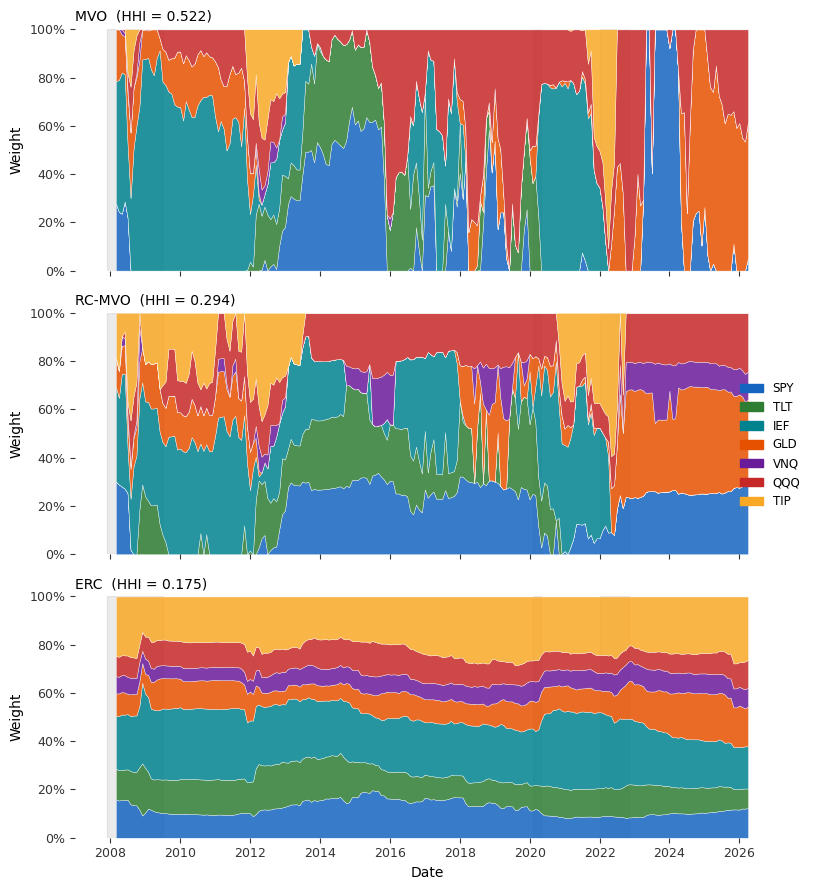

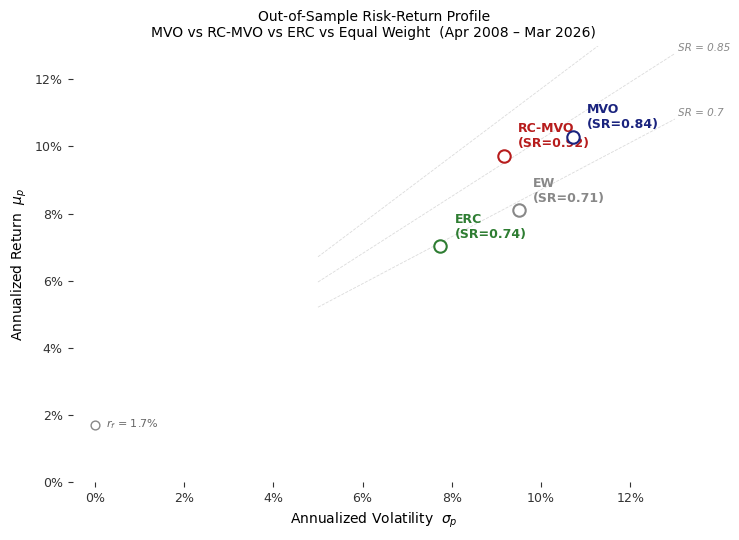

In [14]:
# ── FIGURE A: 3-panel weight evolution comparison ─────────────
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
fig.patch.set_facecolor('white')

asset_colors = ['#1565C0', '#2E7D32', '#00838F',
                '#E65100', '#6A1B9A', '#C62828', '#F9A825']

panels = [
    ('MVO  (HHI = 0.522)',     w_mvo_all,   axes[0]),
    ('RC-MVO  (HHI = 0.294)',  w_rcmvo_all, axes[1]),
    ('ERC  (HHI = 0.175)',     w_erc_all,   axes[2]),
]

for title, w_arr, ax in panels:
    ax.set_facecolor('white')
    ax.stackplot(dates_oos, w_arr.T,
                  colors=asset_colors,
                  alpha=0.85, edgecolor='white',
                  linewidth=0.3)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Weight', fontsize=10)
    ax.set_title(title, fontsize=10, loc='left')
    ax.yaxis.set_major_formatter(
        mtick.PercentFormatter(1.0, decimals=0))
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='#333333', labelsize=9)
    ax.grid(False)

    for rs, re in recession_periods:
        ax.axvspan(pd.Timestamp(rs), pd.Timestamp(re),
                    color='#444444', alpha=0.10, zorder=0)

axes[2].set_xlabel('Date', fontsize=10)

# Single legend on the side
handles = [plt.Rectangle((0,0), 1, 1, color=c) 
            for c in asset_colors]
fig.legend(handles, tickers,
            loc='center right',
            bbox_to_anchor=(1.02, 0.5),
            fontsize=8.5, frameon=False)

plt.tight_layout()
plt.savefig('fig_rcmvo_weights.pdf', dpi=300,
            format='pdf', facecolor='white',
            bbox_inches='tight')
plt.savefig('fig_rcmvo_weights.png', dpi=300,
            facecolor='white', bbox_inches='tight')
plt.show()


# ── FIGURE B: Risk-return scatter with Pareto frontier ──────
fig, ax = plt.subplots(figsize=(7.5, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Plot all three strategies
strategies = [
    ('MVO',    results['MVO']['vol'], 
                results['MVO']['ret'],   
                results['MVO']['sharpe'], '#1A237E'),
    ('RC-MVO', vol_rc, ret_rc, sr_rc,         '#B71C1C'),
    ('ERC',    results['ERC']['vol'], 
                results['ERC']['ret'],   
                results['ERC']['sharpe'], '#2E7D32'),
    ('EW',     results['EW']['vol'],  
                results['EW']['ret'],    
                results['EW']['sharpe'],  '#888888'),
]

for label, v, r, sr, c in strategies:
    ax.scatter(v, r, s=80,
                facecolors='white',
                edgecolors=c, linewidths=1.5,
                zorder=5)
    ax.annotate(
        f'{label}\n(SR={sr:.2f})',
        xy=(v, r),
        xytext=(10, 6),
        textcoords='offset points',
        fontsize=9, color=c,
        fontweight='bold'
    )

# Sharpe ratio iso-lines (lines of constant SR from rf)
rf_avg = rf_monthly.mean() * 12
vol_grid = np.linspace(0.05, 0.13, 100)

iso_sharpes = [0.7, 0.85, 1.0]
for sr_iso in iso_sharpes:
    ret_iso = rf_avg + sr_iso * vol_grid
    ax.plot(vol_grid, ret_iso,
             color='#CCCCCC', lw=0.6,
             ls='--', zorder=2, alpha=0.7)
    ax.annotate(
        f'SR = {sr_iso}',
        xy=(vol_grid[-1], ret_iso[-1]),
        xytext=(2, 2),
        textcoords='offset points',
        fontsize=7.5, color='#888888',
        fontstyle='italic'
    )

# Risk-free point
ax.scatter(0, rf_avg, s=40,
            facecolors='white',
            edgecolors='#888888',
            linewidths=1.0, zorder=5)
ax.annotate(
    f'$r_f$ = {rf_avg:.1%}',
    xy=(0, rf_avg),
    xytext=(8, -2),
    textcoords='offset points',
    fontsize=8, color='#666666'
)

ax.set_xlabel('Annualized Volatility  $\\sigma_p$',
              fontsize=10)
ax.set_ylabel('Annualized Return  $\\mu_p$',
              fontsize=10)
ax.set_title(
    'Out-of-Sample Risk-Return Profile\n'
    'MVO vs RC-MVO vs ERC vs Equal Weight  '
    '(Apr 2008 – Mar 2026)',
    fontsize=10
)
ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0, decimals=0))

ax.set_xlim(-0.005, 0.13)
ax.set_ylim(0, 0.13)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors='#333333', labelsize=9)
ax.grid(False)

plt.tight_layout()
plt.savefig('fig_riskreturn.pdf', dpi=300,
            format='pdf', facecolor='white')
plt.savefig('fig_riskreturn.png', dpi=300,
            facecolor='white')
plt.show()

/var/folders/d4/091mk2ld0z77zrqkvzvgfyhc0000gn/T/ipykernel_49133/3230607456.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap('RdYlGn')


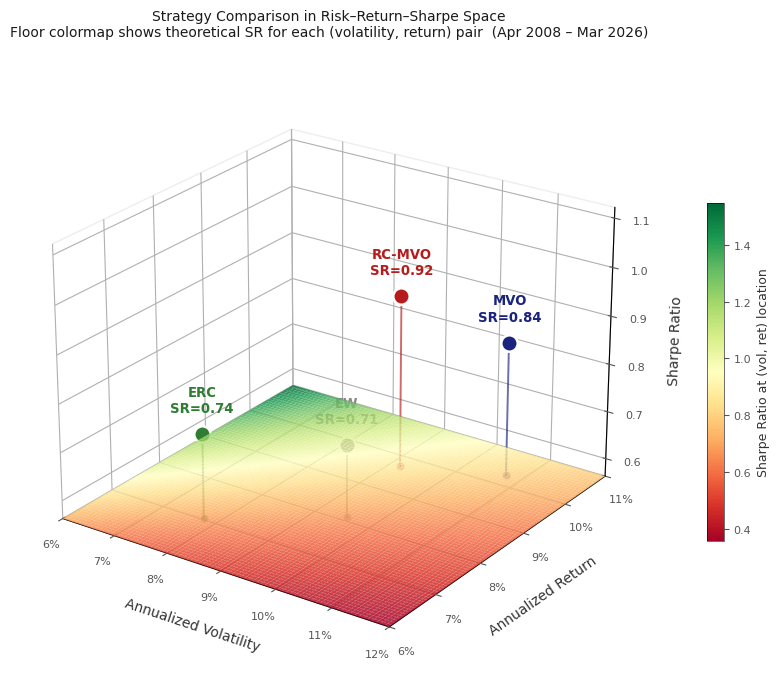

In [20]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(9, 7))
fig.patch.set_facecolor('white')
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# ── Sharpe ratio floor (flat color plane on z = z_floor) ─────
rf_avg   = rf_monthly.mean() * 12
vol_grid = np.linspace(0.06, 0.12, 80)
ret_grid = np.linspace(0.06, 0.11, 80)
V, R     = np.meshgrid(vol_grid, ret_grid)
SR_field = (R - rf_avg) / V

# Floor Z-position — slightly below lowest data point
sr_min   = min(s['sr'] for s in strategies.values())
sr_max   = max(s['sr'] for s in strategies.values())
z_floor  = sr_min - 0.15
Z_floor  = np.full_like(V, z_floor)

# Normalize for colormap
norm   = mcolors.Normalize(
    vmin=SR_field.min(), 
    vmax=SR_field.max())
cmap   = cm.get_cmap('RdYlGn')
colors_floor = cmap(norm(SR_field))

surf = ax.plot_surface(
    V, R, Z_floor,
    facecolors=colors_floor,
    rstride=1, cstride=1,
    shade=False,
    edgecolor='none',
    antialiased=True,
    alpha=0.85
)

# Colorbar
mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])
cbar = fig.colorbar(
    mappable, ax=ax,
    pad=0.08, shrink=0.55,
    aspect=20)
cbar.set_label('Sharpe Ratio at (vol, ret) location',
                fontsize=9, color='#333333')
cbar.ax.tick_params(labelsize=8, colors='#555555')
cbar.outline.set_linewidth(0.4)

# ── Strategy data ─────────────────────────────────────────────
strategies = {
    'MVO'    : {'vol': results['MVO']['vol'],
                'ret': results['MVO']['ret'],
                'sr' : results['MVO']['sharpe'],
                'col': '#1A237E'},
    'RC-MVO' : {'vol': vol_rc,
                'ret': ret_rc,
                'sr' : sr_rc,
                'col': '#B71C1C'},
    'ERC'    : {'vol': results['ERC']['vol'],
                'ret': results['ERC']['ret'],
                'sr' : results['ERC']['sharpe'],
                'col': '#2E7D32'},
    'EW'     : {'vol': results['EW']['vol'],
                'ret': results['EW']['ret'],
                'sr' : results['EW']['sharpe'],
                'col': '#888888'},
}

# ── Drop lines from floor to each strategy point ──────────────
for name, s in strategies.items():
    # vertical line from floor up to actual SR
    ax.plot(
        [s['vol'], s['vol']],
        [s['ret'], s['ret']],
        [z_floor, s['sr']],
        color=s['col'], lw=1.4,
        alpha=0.65
    )

    # marker on floor
    ax.scatter(
        s['vol'], s['ret'], z_floor,
        color=s['col'], s=35,
        alpha=0.5,
        edgecolors='white',
        linewidths=0.8,
        depthshade=False
    )

    # main marker at SR height
    ax.scatter(
        s['vol'], s['ret'], s['sr'],
        color=s['col'],
        s=140,
        edgecolors='white',
        linewidths=1.8,
        depthshade=False,
        zorder=10
    )

    ax.text(
        s['vol'], s['ret'], s['sr'] + 0.04,
        f"{name}\nSR={s['sr']:.2f}",
        fontsize=9.5,
        fontweight='bold',
        color=s['col'],
        ha='center', va='bottom'
    )

# ── Axes formatting ──────────────────────────────────────────
ax.set_xlabel('\nAnnualized Volatility',
               fontsize=10, color='#333333')
ax.set_ylabel('\nAnnualized Return',
               fontsize=10, color='#333333')
ax.set_zlabel('\nSharpe Ratio',
               fontsize=10, color='#333333')

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(1.0, decimals=0))

ax.set_xlim(0.06, 0.12)
ax.set_ylim(0.06, 0.11)
ax.set_zlim(z_floor, sr_max + 0.20)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#DDDDDD')
ax.yaxis.pane.set_edgecolor('#DDDDDD')
ax.zaxis.pane.set_edgecolor('#DDDDDD')

ax.tick_params(colors='#555555', labelsize=8)
ax.grid(True, alpha=0.15)
ax.view_init(elev=24, azim=-55)

ax.set_title(
    'Strategy Comparison in Risk–Return–Sharpe Space\n'
    'Floor colormap shows theoretical SR for each '
    '(volatility, return) pair  (Apr 2008 – Mar 2026)',
    fontsize=10, color='#1a1a1a', pad=20
)

plt.tight_layout()
plt.savefig('fig_3d_sharpe_surface.pdf', dpi=300,
            format='pdf', facecolor='white',
            bbox_inches='tight')
plt.savefig('fig_3d_sharpe_surface.png', dpi=300,
            facecolor='white', bbox_inches='tight')
plt.show()